In [1]:
import os
import glob

import torch
torch.set_default_dtype(torch.double)
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision  
import matplotlib.pyplot as plt
from tqdm import tqdm
from nflows.distributions import StandardNormal
from nflows.flows import Flow
from nflows.transforms.normalization import ActNorm
from nflows.transforms import OneByOneConvolution, SqueezeTransform

# concave
from src.concaves.log import LogConcave

# diffeomorphisms
from src.diffeomorphisms.composition.image import ImageCompositionDiffeomorphism
from src.diffeomorphisms.image.concave import ConcaveImageDiffeomorphism
from src.diffeomorphisms.image.nflow import NFlowImageDiffeomorphism
from src.diffeomorphisms.image.star import StarImageDiffeomorphism

# dimension reduction
from src.dimension_reduction.archetypal_analysis import ArchetypalAnalysisSolver

# manifolds
from src.manifolds.euclidean.image.pullback.standard import StandardPullbackImageEuclidean
from src.manifolds.euclidean.image.standard import StandardImageEuclidean
from src.manifolds.isometrized_euclidean.image import l2IsometrizedImageEuclidean

# nflow training
from src.nflow_training import NFlowTraining

# RAM
from src.nn.module.riemannian.archetypal_mapping import RiemannianArchetypalMapping

# star construction
from src.star_construction import StarConstruction

# transforms
from src.transforms.composite.image import ImageCompositeTransform
from src.transforms.image import ImageTransform
from src.transforms.image.parity_conv.linear_2d import Linear2DParityConvImageTransform
from src.transforms.image.parity_conv.simple_tanh_2d import SimpleTanh2DParityConvImageTransform

from config_loader import load_experiment_config 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# set random seed
torch.manual_seed(31)

# declare exp name
exp_name = "multi_ellipsoid_starflow"

# ---- load YAML config ----
config = load_experiment_config(os.path.join("configs", "mnist", exp_name + ".yaml"), "mnist_32")

data_cfg = config["data"]
nflow_cfg = config["nflow"]
starflow_cfg = config["starflow"]

size = data_cfg["size"]
batch_size = data_cfg["batch_size"]

nflow_training = nflow_cfg["enabled"]
starflow_training = starflow_cfg["enabled"]

base_results_folder = os.path.join("results", "mnist", exp_name)
os.makedirs(base_results_folder, exist_ok=True)

results_folder = os.path.join(
    base_results_folder,
    f"{size}x{size}",
)
os.makedirs(results_folder, exist_ok=True)


Using NumPy backend


In [2]:
H = W = size
mnist_mean = data_cfg["mnist_mean"]
mnist_var = data_cfg["mnist_var"]
train_val_split = data_cfg["train_val_split"]

transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((H, W)),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((mnist_mean,), (mnist_var,))
])

full_dataset = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform)

# Collect all images and labels
data = []
labels = []

for x, y in full_dataset:
    data.append(x)          # x has shape 1 x H x W
    labels.append(y)

# Stack into tensors
data = torch.stack(data, dim=0)        # shape: N x 1 x H x W
labels = torch.tensor(labels, dtype=torch.long)  # shape: N

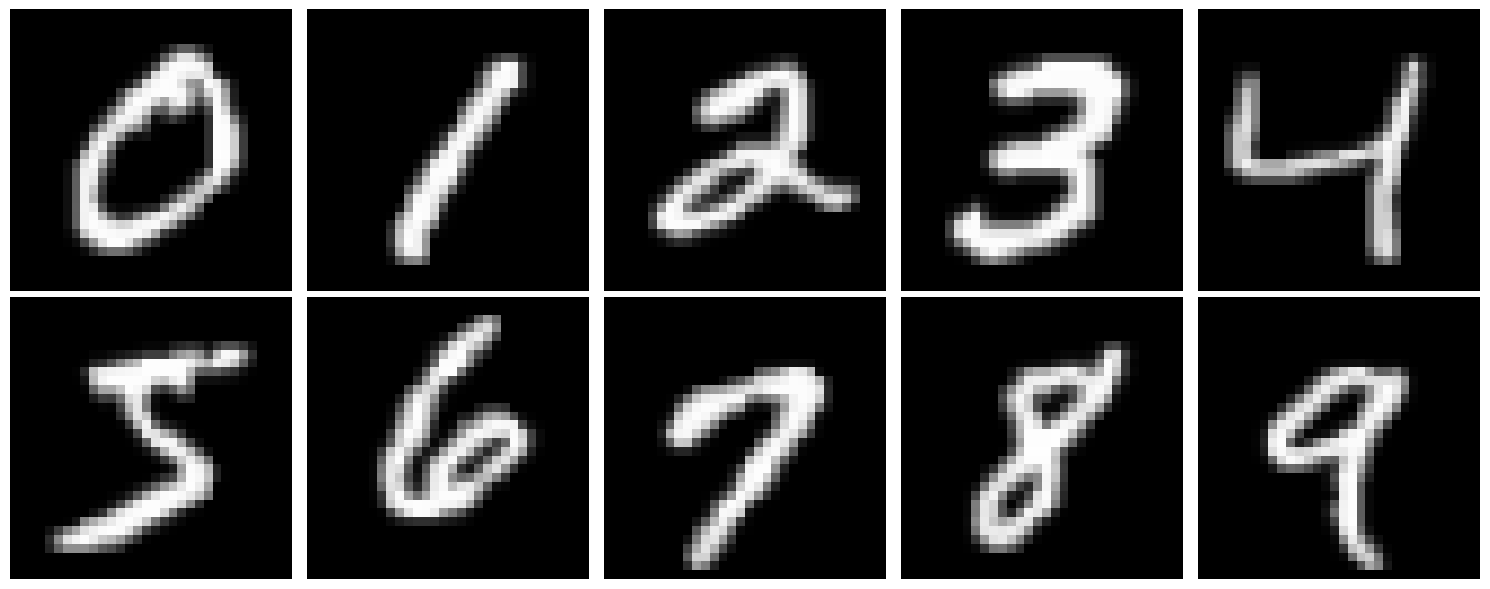

In [3]:
# construct data clusters as one digit per class
data_clusters = torch.zeros((10, 1, H, W))  # placeholder for cluster images
for digit in range(10):
    digit_indices = (labels == digit)
    data_clusters[digit] = data[digit_indices][0]

labels_clusters = torch.arange(10)

# plot cluster images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()
for i in range(10):
    axes[i].imshow(data_clusters[i].squeeze(), cmap='gray', vmin=data.min(), vmax=data.max())
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [4]:
# construct train and val datasets
data_size = data.shape[0]
train_size = int(train_val_split * data_size)
val_size = data_size - train_size
idx = torch.randperm(data_size)
train_idx, val_idx = idx[:train_size], idx[train_size:]
data_train, data_val = data[train_idx], data[val_idx]
labels_train, labels_val = labels[train_idx], labels[val_idx]

print("Data shapes: \n data.shape = {} \n data_train.shape = {} \n data_val.shape = {}".format(data.shape, data_train.shape, data_val.shape))

Data shapes: 
 data.shape = torch.Size([60000, 1, 32, 32]) 
 data_train.shape = torch.Size([48000, 1, 32, 32]) 
 data_val.shape = torch.Size([12000, 1, 32, 32])


In [5]:
# create dataset and dataloader
train_loader = DataLoader(data_train, batch_size=batch_size, shuffle=False)

## Learn an NFlow ##

In [6]:
class MultiLevelImageTransform(ImageTransform):
    def __init__(self, in_channels, height, width, image_transforms):
        """
        :param image_transforms: list of ImageTransform objects, one for each level of the multi-level transform.
        """
        self.L = len(image_transforms)
        assert image_transforms[0].C == in_channels * 4
        assert image_transforms[0].H == height // 2
        assert image_transforms[0].W == width // 2
        # assert that the image transform dimensions shrink by a factor of 2 at each level, but channels grow by a factor of 2 at each level
        assert all(image_transforms[i].C == image_transforms[i-1].C * 2 for i in range(1, self.L))
        assert all(image_transforms[i].H == image_transforms[i-1].H // 2 for i in range(1, self.L))
        assert all(image_transforms[i].W == image_transforms[i-1].W // 2 for i in range(1, self.L))
        super().__init__(in_channels, height, width)
        self.image_transforms = nn.ModuleList(image_transforms)

        self.squeeze = SqueezeTransform(factor=2)
        

    def forward(self, inputs, context=None):
        batch_size = inputs.shape[0]
        outputs = inputs
        total_logabsdet = inputs.new_zeros(batch_size)
        splits = []
        for i in range(self.L):
            # squeeze
            outputs, log_abs_det = self.squeeze(outputs, None)
            total_logabsdet += log_abs_det

            # flow step
            outputs, log_abs_det = self.image_transforms[i](outputs, None)
            total_logabsdet += log_abs_det

            # split
            split, outputs = torch.chunk(outputs, 2, dim=1)
            splits.append(split)

        # add context if provided
        if context is not None:
            assert context.shape[0] == batch_size
            assert context.shape[1] == self.image_transforms[-1].H
            assert context.shape[2] == self.image_transforms[-1].W
            context_ = torch.zeros_like(outputs)
            context_[:, 0] = context
            outputs = outputs - context_

        # iterate through splits to get outputs in correct order
        for i in reversed(range(self.L)):
            # concatenate split back to outputs
            outputs = torch.cat([splits[i], outputs], dim=1)
            # unsqueeze
            outputs, _ = self.squeeze.inverse(outputs, None)

        return outputs, total_logabsdet
    
    def inverse(self, inputs, context=None):
        # iterate through splits to get outputs in correct order
        outputs = inputs
        splits = []
        for i in range(self.L):
            # squeeze
            outputs, _ = self.squeeze(outputs, None)

            split, outputs = torch.chunk(outputs, 2, dim=1)
            splits.append(split)

        # remove context if provided
        if context is not None:
            assert context.shape[0] == inputs.shape[0]
            assert context.shape[1] == self.image_transforms[-1].H
            assert context.shape[2] == self.image_transforms[-1].W
            context_ = torch.zeros_like(outputs)
            context_[:, 0] = context
            outputs = outputs + context_

        total_logabsdet = inputs.new_zeros(inputs.shape[0])
        for i in reversed(range(self.L)):
            # concatenate
            outputs = torch.cat([splits[i], outputs], dim=1)

            # flow step
            outputs, log_abs_det = self.image_transforms[i].inverse(outputs, None)
            total_logabsdet += log_abs_det

            # unsqueeze
            outputs, log_abs_det = self.squeeze.inverse(outputs, None)
            total_logabsdet += log_abs_det

        return outputs, total_logabsdet

In [7]:
class SimpleMultiLevelImageTransform(MultiLevelImageTransform):
    def __init__(self, in_channels, height, width, kernel_size=3, hidden_channels=64, n_flows=3, n_scales=3):
        super().__init__(in_channels, height, width, [self.create_transform(in_channels * (2 ** i) * 2, height // (2 ** i), width // (2 ** i), kernel_size, hidden_channels, n_flows) for i in range(1, n_scales+1)])

    def create_transform(self, in_channels, height, width, kernel_size, hidden_channels, n_flows):
        transforms_list = []
        # stack n_flows coupling layers with ActNorm in between, using parity to alternate which pixels are transformed
        for i in range(n_flows):
            transforms_list.append(ActNorm(features=in_channels)) # OneByOneConvolution
            transforms_list.append(OneByOneConvolution(in_channels))
            transforms_list.append(Linear2DParityConvImageTransform(in_channels, height, width, kernel_size, parity=i))
            transforms_list.append(Linear2DParityConvImageTransform(in_channels, height, width, kernel_size, parity=i+1))
            transforms_list.append(SimpleTanh2DParityConvImageTransform(in_channels, height, width, hidden_channels=hidden_channels, kernel_size=kernel_size, parity=i))
        transforms_list.append(ActNorm(features=in_channels))
        transforms_list.append(OneByOneConvolution(in_channels))
        transforms_list.append(Linear2DParityConvImageTransform(in_channels, height, width, kernel_size, parity=n_flows))
        transforms_list.append(Linear2DParityConvImageTransform(in_channels, height, width, kernel_size, parity=n_flows+1))
        transform = ImageCompositeTransform(in_channels, height, width, transforms_list)
        return transform

In [8]:
# construct nflow and trainer
nflow = Flow(transform=SimpleMultiLevelImageTransform(in_channels=1, height=H, width=W, kernel_size=nflow_cfg["kernel_size"], hidden_channels=nflow_cfg["hidden_channels"], n_flows=nflow_cfg["n_flows"], n_scales=nflow_cfg["n_scales"]),
             distribution=StandardNormal(shape=[1, H, W])).to(device)

nflow_trainer = NFlowTraining(nflow)

In [9]:
# construct train loop
def train_nflow(trainer, train_loader, save_dir, n_epochs, start_epoch=0, best_loss=float('inf'), save_every=10):
    for epoch in range(start_epoch, n_epochs):
        epoch_loss = 0.0
        for x in tqdm(train_loader):
            x = x.to(device, non_blocking=True)
            loss = trainer.train_step(x)
            epoch_loss += loss * x.size(0)
        epoch_loss /= len(train_loader.dataset)
        print(f"Epoch {epoch+1}/{n_epochs}, Loss: {epoch_loss:.6f}")

        # Save checkpoint
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': trainer.nflow.state_dict(),
            'optimizer_state_dict': trainer.optimizer.state_dict(),
            'loss': epoch_loss,
            'best_loss': best_loss,
        }
        if (epoch+1) % save_every == 0 or (epoch+1) == n_epochs:
            torch.save(checkpoint, os.path.join(save_dir, f'epoch_{epoch+1}_model.pth'))

        if epoch_loss < best_loss:
            best_loss = epoch_loss
            torch.save(checkpoint, os.path.join(save_dir, 'best_model.pth'))

    print("Training completed. Best model saved with loss:", best_loss)

In [10]:
# train or load nflow model
nflow_extension = f"lr_{nflow_cfg['learning_rate']}_kernel_{nflow_cfg['kernel_size']}_hidden_{nflow_cfg['hidden_channels']}_flows_{nflow_cfg['n_flows']}_scales_{nflow_cfg['n_scales']}"
checkpoint_dir = os.path.join(results_folder, nflow_cfg["checkpoint_subdir"], nflow_extension)
os.makedirs(checkpoint_dir, exist_ok=True)

if nflow_training:
    start_epoch = 0
    best_loss = float('inf')
    latest_checkpoint = max(
        glob.glob(os.path.join(checkpoint_dir, "epoch_*_model.pth")),
        default=None,
        key=os.path.getctime,
    )

    if latest_checkpoint:
        print(f"Resuming training from {latest_checkpoint}")
        checkpoint = torch.load(latest_checkpoint)
        nflow_trainer.nflow.load_state_dict(checkpoint["model_state_dict"])
        nflow_trainer.optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        start_epoch = checkpoint["epoch"] + 1
        best_loss = checkpoint["best_loss"]

    train_nflow(
        nflow_trainer,
        train_loader,
        save_dir=checkpoint_dir,
        n_epochs=nflow_cfg["num_epochs"],
        start_epoch=start_epoch,
        best_loss=best_loss,
    )
else:
    best_model_path = os.path.join(checkpoint_dir, "best_model.pth")
    checkpoint = torch.load(best_model_path, map_location=device)
    nflow_trainer.nflow.load_state_dict(checkpoint["model_state_dict"])

In [11]:
# construct diffeomorphism from nflow
phi = NFlowImageDiffeomorphism(1, H, W, nflow_trainer.nflow)

In [12]:
# construct pullback manifold and ref manifold
phi_manifold = StandardPullbackImageEuclidean(phi)
l2_euclidean = StandardImageEuclidean(1, H, W)

/Users/wdiepeveen/Documents/Postdoc/projects/6 - Lyme Geometry/Lyme-Geometry/.venv/lib/python3.13/site-packages/nflows/transforms/lu.py:80: UserWarning: torch.triangular_solve is deprecated in favor of torch.linalg.solve_triangularand will be removed in a future PyTorch release.
torch.linalg.solve_triangular has its arguments reversed and does not return a copy of one of the inputs.
X = torch.triangular_solve(B, A).solution
should be replaced with
X = torch.linalg.solve_triangular(A, B). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/BatchLinearAlgebra.cpp:2270.)
  outputs, _ = torch.triangular_solve(


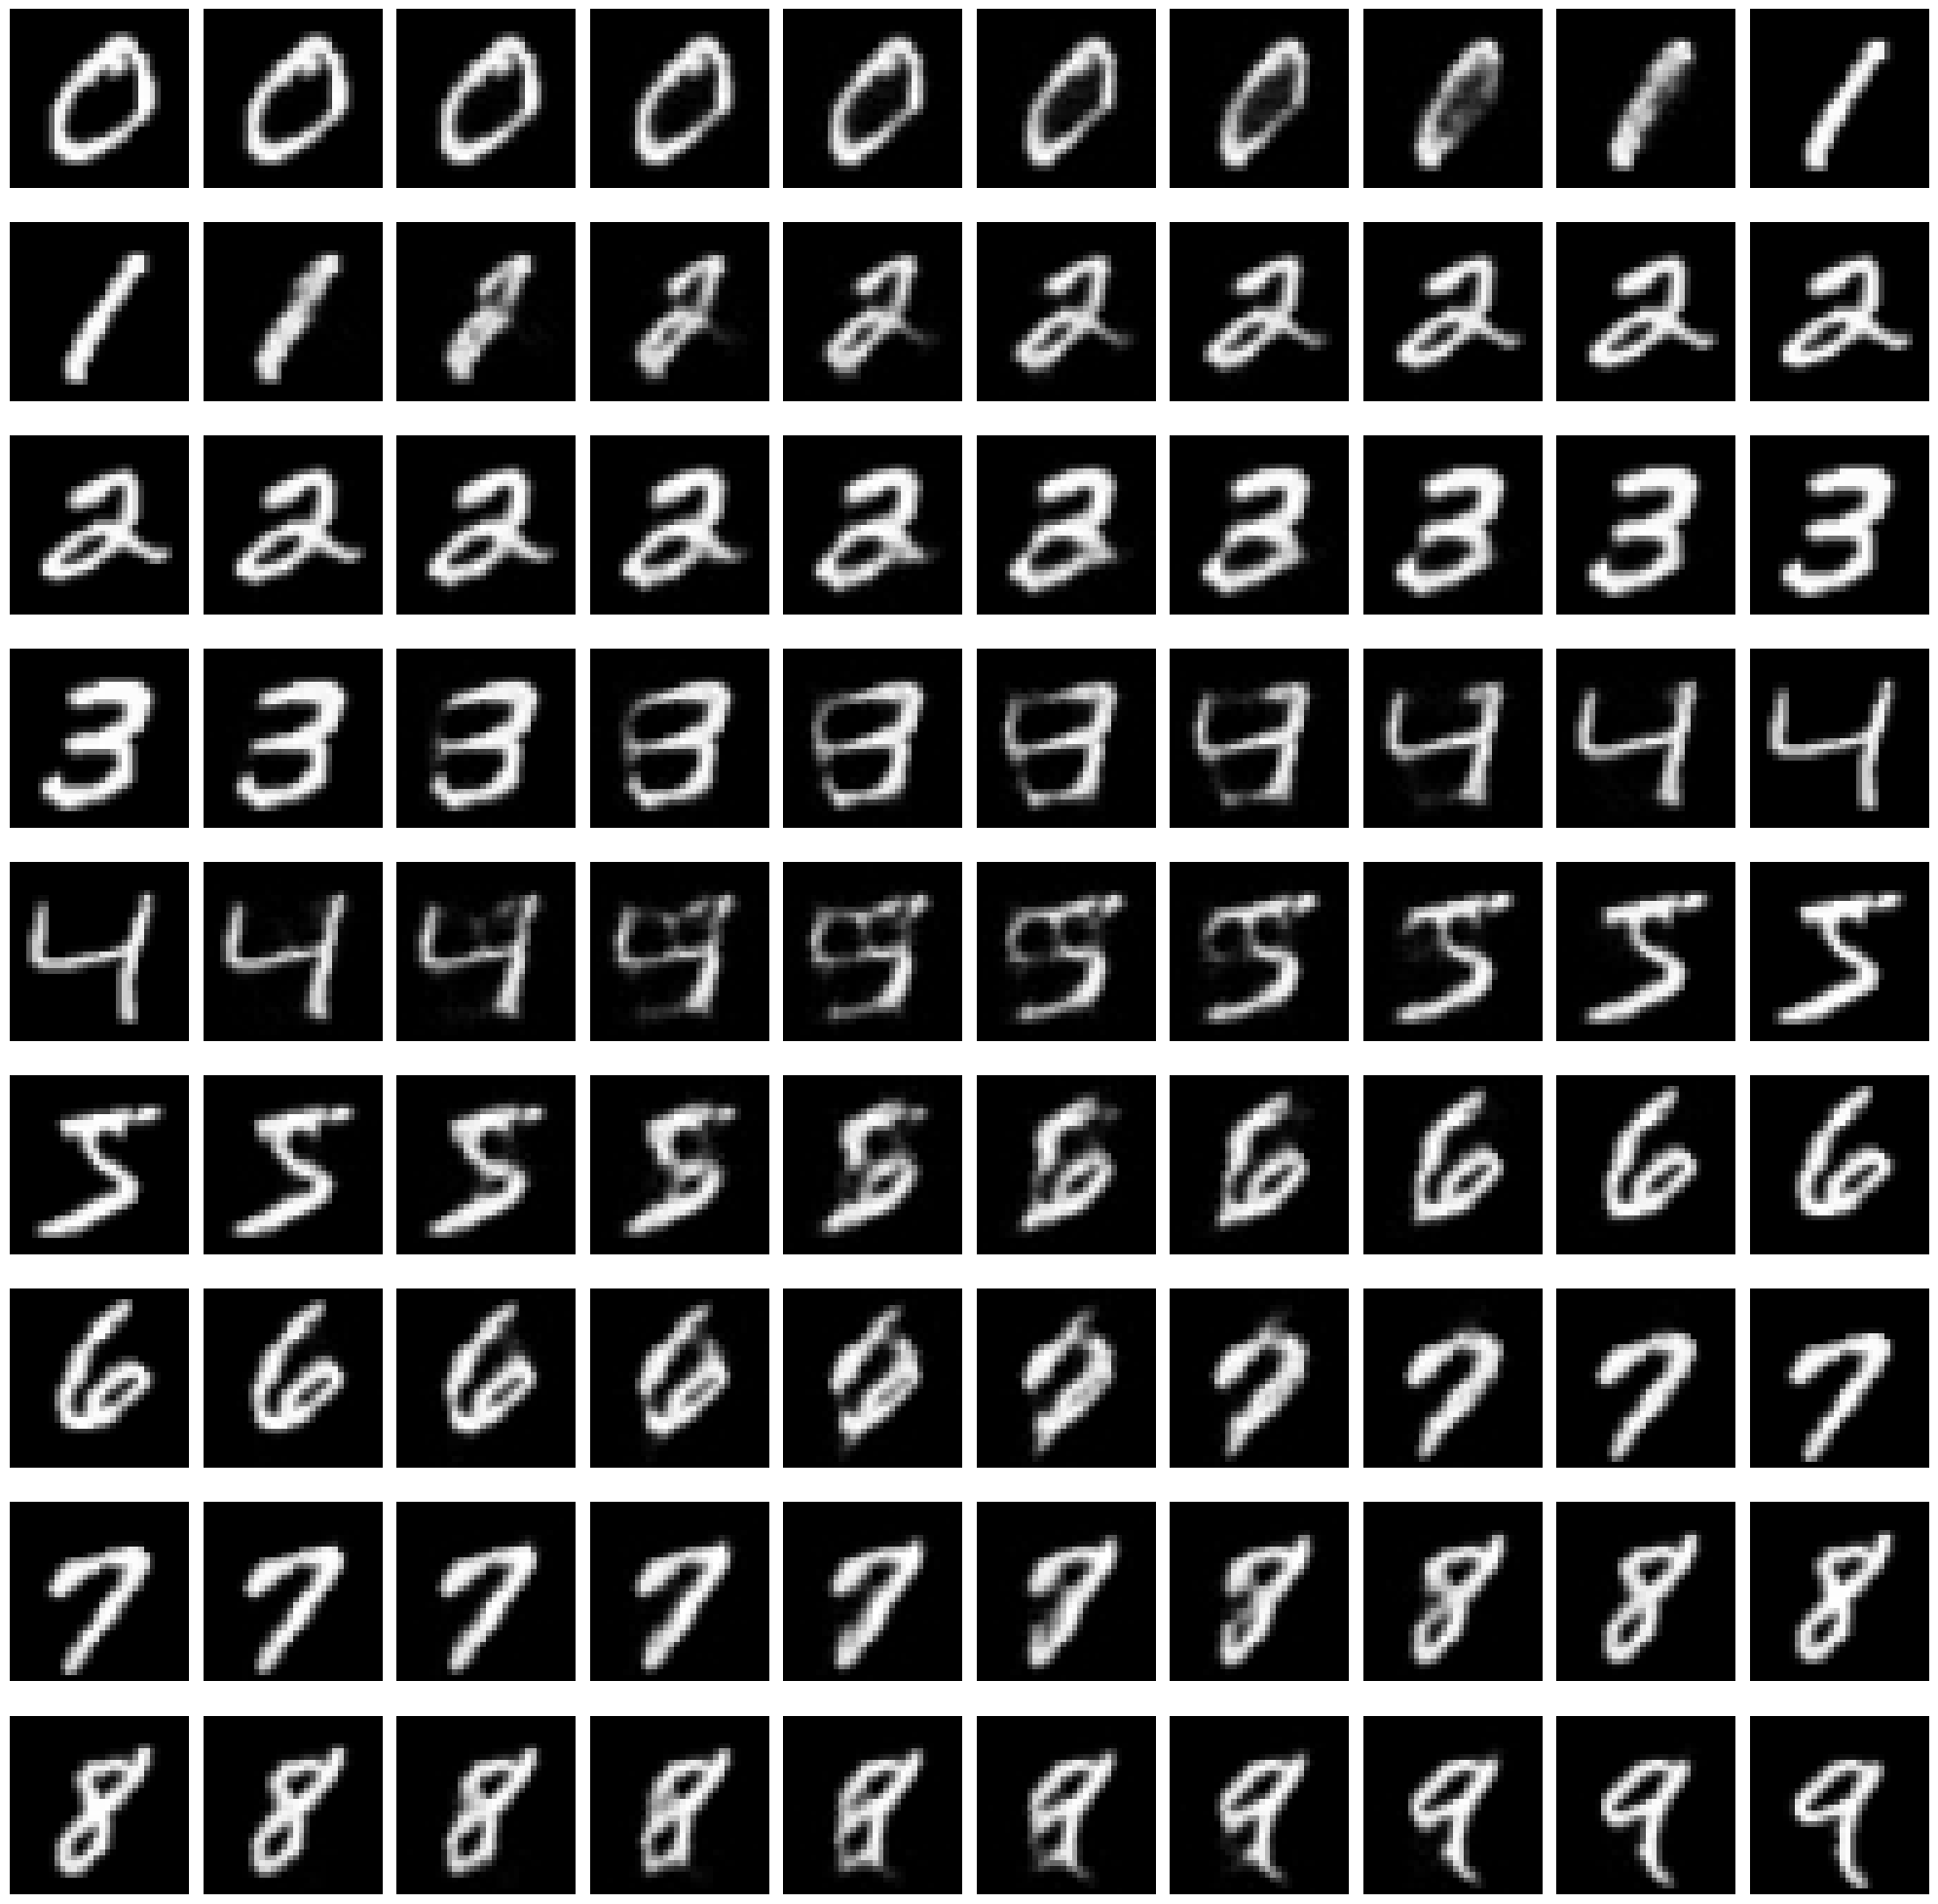

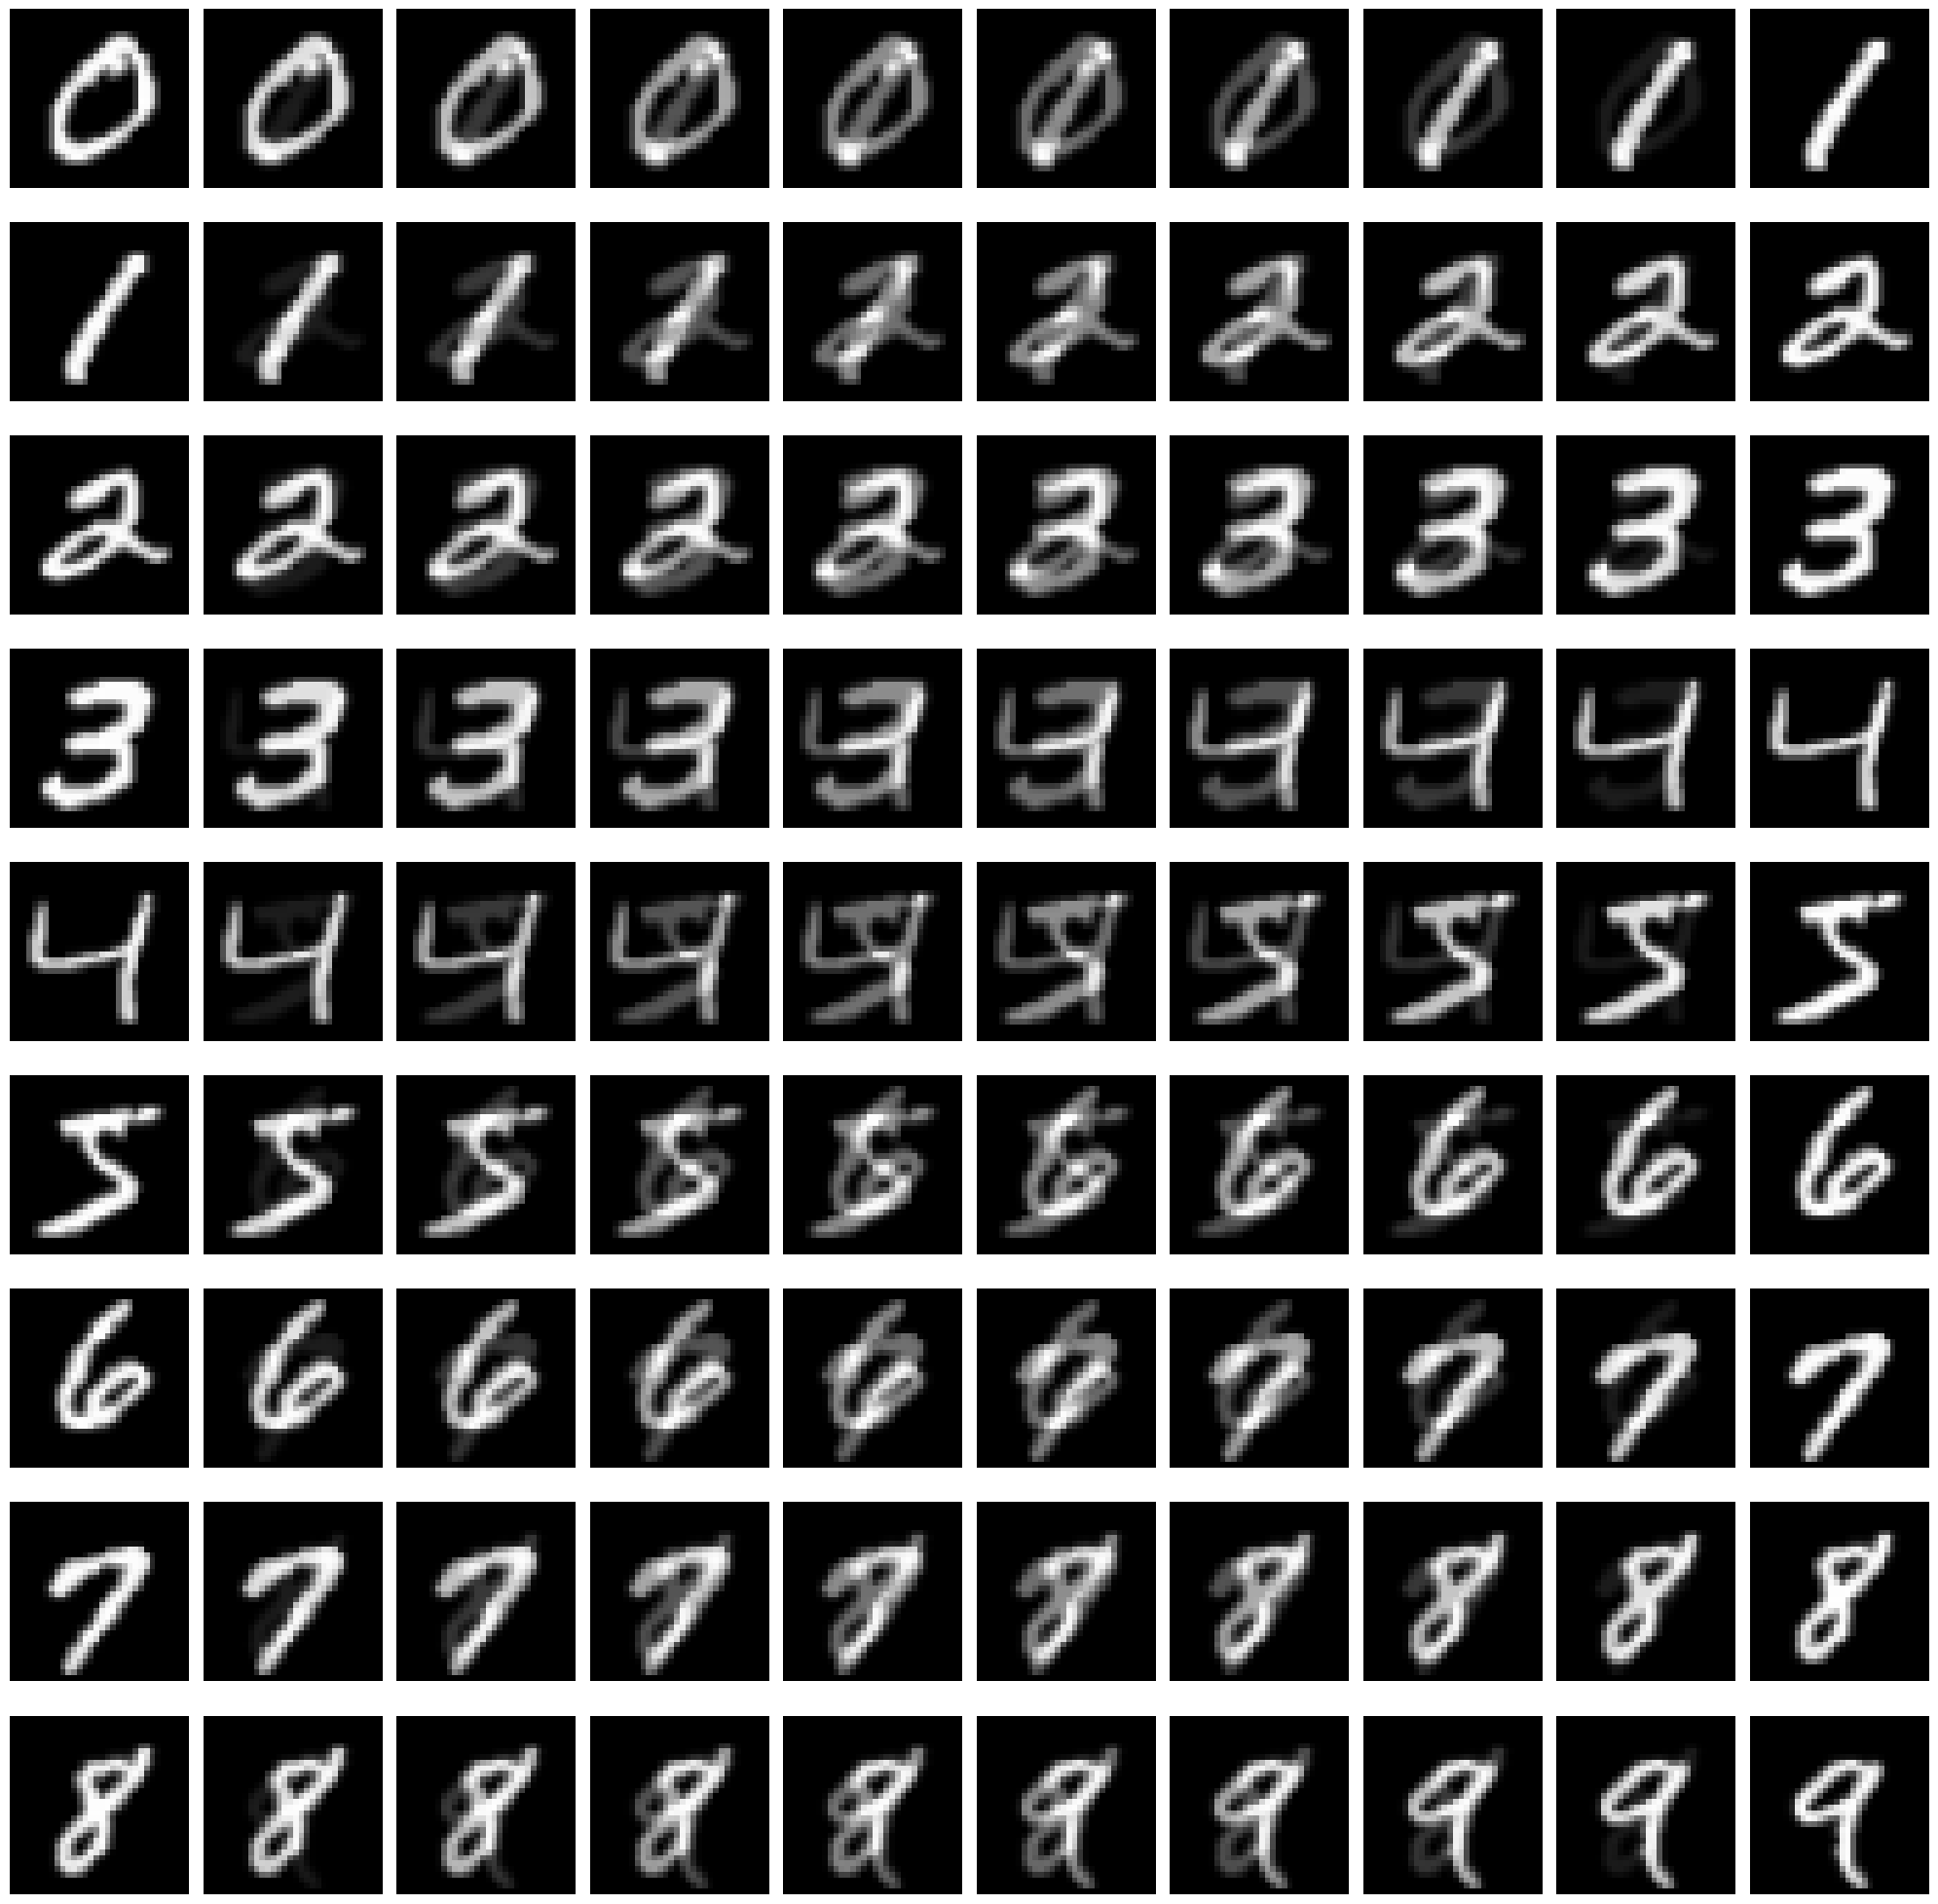

In [13]:
# compute geodesics between all pairs of points
steps = 10
t = torch.linspace(0, 1, steps=steps)
with torch.no_grad():
    phi_geodesics = phi_manifold.geodesic(data_clusters[None].to(device), data_clusters[None].to(device), t.to(device))[0].cpu()
    interpolations = l2_euclidean.geodesic(data_clusters[None], data_clusters[None], t)[0]

# plot geodesics
fig, axes = plt.subplots(9, steps, figsize=(int(steps / 10 * 20), 20))
axes = axes.flatten()
for i in range(10-1):
    for k in range(steps):
        axes[i*steps + k].imshow(phi_geodesics[i, i+1, k, 0], cmap='gray', vmin=data.min(), vmax=data.max())
        axes[i*steps + k].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(results_folder,"geodesics_phi.png"))
plt.show()

# plot interpolations
fig, axes = plt.subplots(9, steps, figsize=(int(steps / 10 * 20), 20))
axes = axes.flatten()
for i in range(10-1):
    for k in range(steps): # have same color scale for all plots
        axes[i*steps + k].imshow(interpolations[i, i+1, k, 0], cmap='gray', vmin=data.min(), vmax=data.max())
        axes[i*steps + k].axis('off')  
plt.tight_layout()
plt.savefig(os.path.join(results_folder,"linear_interpolations.png"))
plt.show()

## Learn a Latent Space Star ##

In [14]:
phi_data_train = torch.zeros_like(data_train)
i = 0
with torch.no_grad():
    for x in tqdm(train_loader):
        x = x.to(device, non_blocking=True)
        b = x.size(0)                      # actual batch size
        phi_data_train[i:i+b] = phi(x).cpu()
        i += b
    phi_data_clusters = phi(data_clusters.to(device)).cpu()

100%|██████████| 375/375 [00:36<00:00, 10.27it/s]


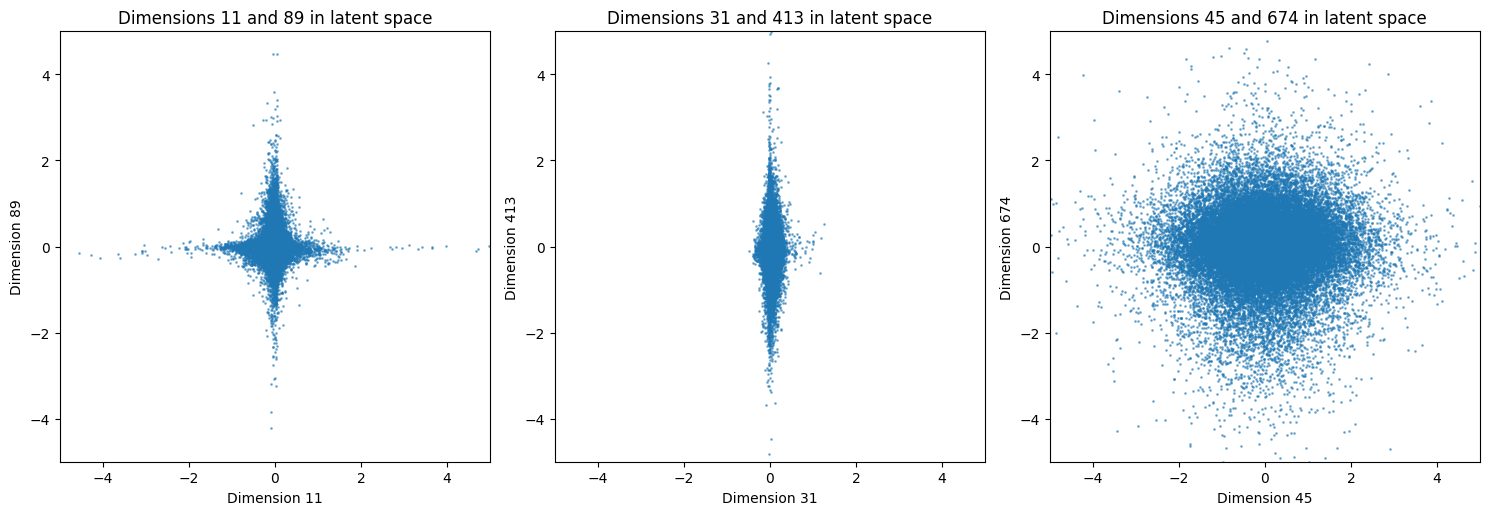

In [15]:
# plot first two dimensions of phi_data_train
dims_1 = [11, 89]
dims_2 = [31, 413]
dims_3 = [45, 674]

# three scatter plots of different dimensions of phi_data_train
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].scatter(phi_data_train.reshape(-1, size*size)[:, dims_1[0]].numpy(), phi_data_train.reshape(-1, size*size)[:, dims_1[1]].numpy(), s=1, alpha=0.5)
ax[0].set_title(f"Dimensions {dims_1[0]} and {dims_1[1]} in latent space")
ax[0].set_xlabel(f"Dimension {dims_1[0]}")
ax[0].set_ylabel(f"Dimension {dims_1[1]}")
ax[0].set_aspect('equal', adjustable='box')
ax[0].set_xlim(-5, 5)
ax[0].set_ylim(-5, 5)

ax[1].scatter(phi_data_train.reshape(-1, size*size)[:, dims_2[0]].numpy(), phi_data_train.reshape(-1, size*size)[:, dims_2[1]].numpy(), s=1, alpha=0.5)
ax[1].set_title(f"Dimensions {dims_2[0]} and {dims_2[1]} in latent space")
ax[1].set_xlabel(f"Dimension {dims_2[0]}")
ax[1].set_ylabel(f"Dimension {dims_2[1]}")
ax[1].set_aspect('equal', adjustable='box')
ax[1].set_xlim(-5, 5)
ax[1].set_ylim(-5, 5)

ax[2].scatter(phi_data_train.reshape(-1, size*size)[:, dims_3[0]].numpy(), phi_data_train.reshape(-1, size*size)[:, dims_3[1]].numpy(), s=1, alpha=0.5)
ax[2].set_title(f"Dimensions {dims_3[0]} and {dims_3[1]} in latent space")
ax[2].set_xlabel(f"Dimension {dims_3[0]}")
ax[2].set_ylabel(f"Dimension {dims_3[1]}")
ax[2].set_aspect('equal', adjustable='box')
ax[2].set_xlim(-5, 5)
ax[2].set_ylim(-5, 5)
plt.tight_layout()
plt.show()

In [16]:
# compute barycentre and logs
with torch.no_grad():
    phi_barycentre = phi.inverse(phi_data_train.mean(dim=0, keepdim=True).to(device)).cpu()

phi_logs_data_train = torch.zeros_like(data_train)
i = 0
with torch.no_grad():
    for x in tqdm(train_loader):
        x = x.to(device, non_blocking=True)
        b = x.size(0)                      # actual batch size
        phi_logs_data_train[i:i+b] = phi_manifold.log(phi_barycentre.to(device)[None], x[None]).cpu()[0,0]
        i += b

100%|██████████| 375/375 [03:04<00:00,  2.03it/s]


### Supervised ###

In [ ]:
# construct archetypes

In [ ]:
# construct star from archetypes
supervised_trainer = StarConstruction(10, n_archetypes=10, trimmed=True)

In [19]:
# use labels to compute cluster means and variances in phi space
supervised_trainer.fit(phi_data_train.reshape(phi_data_train.shape[0], -1), labels=labels_train)

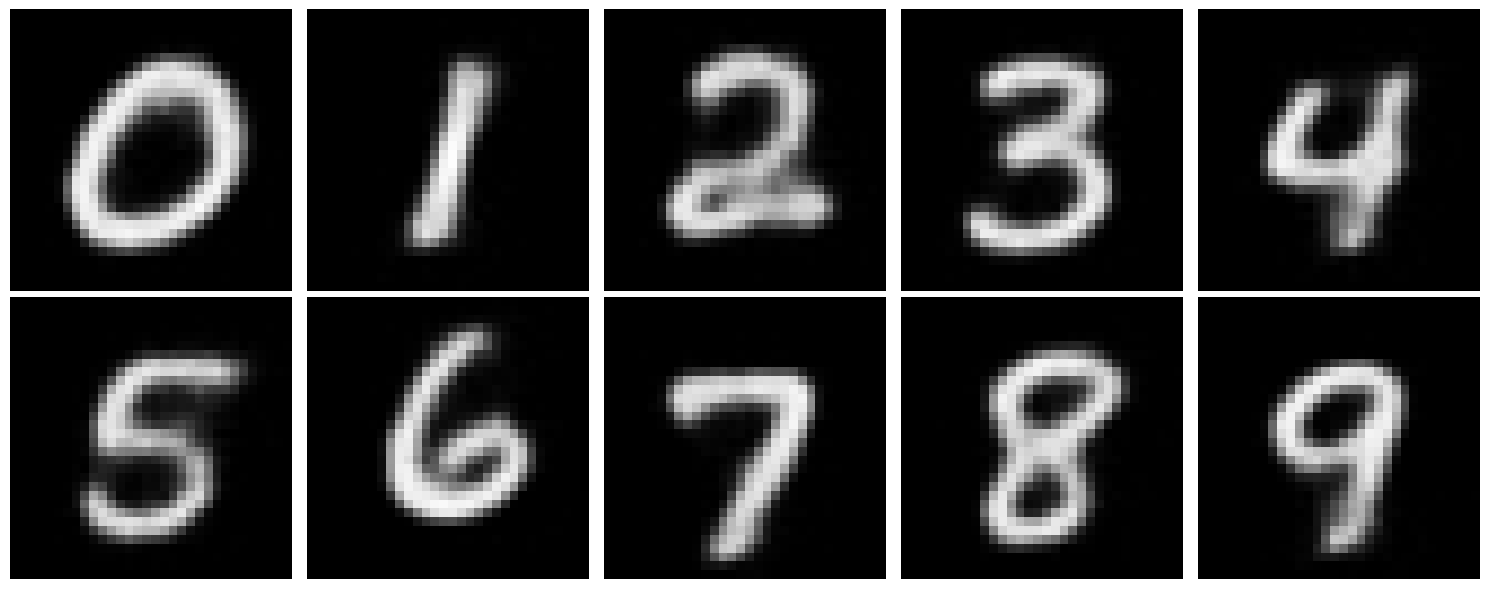

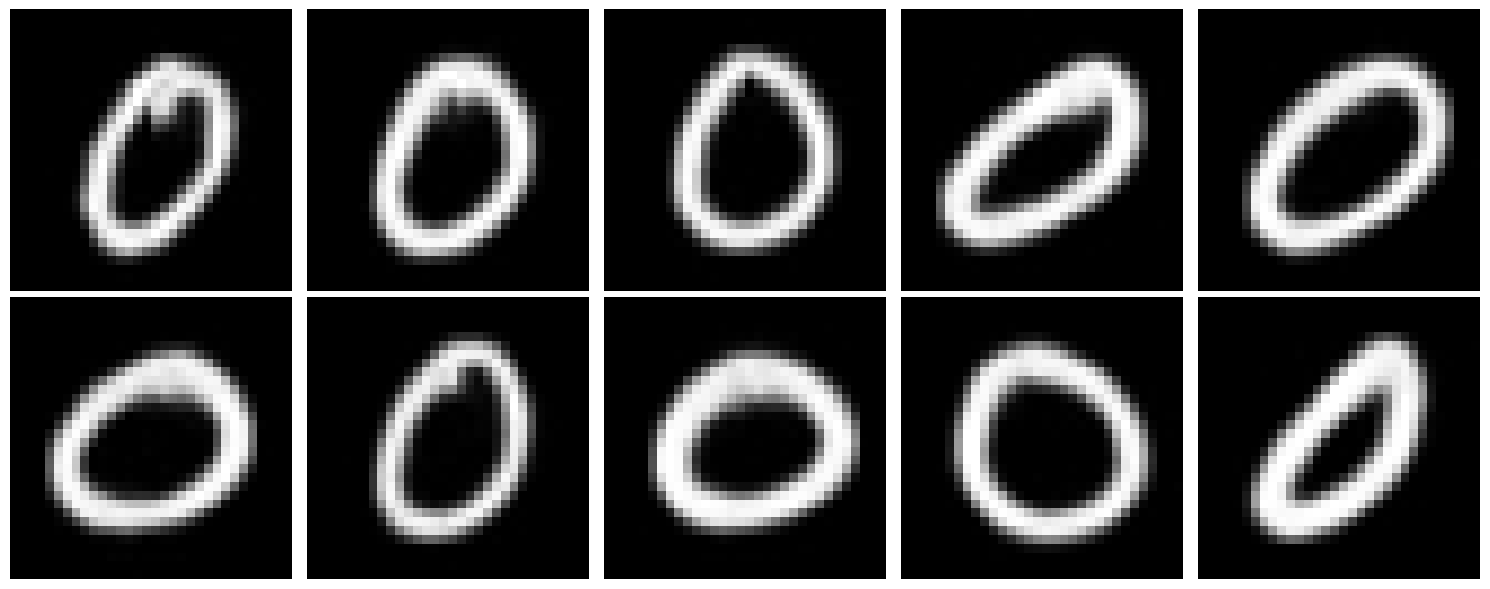

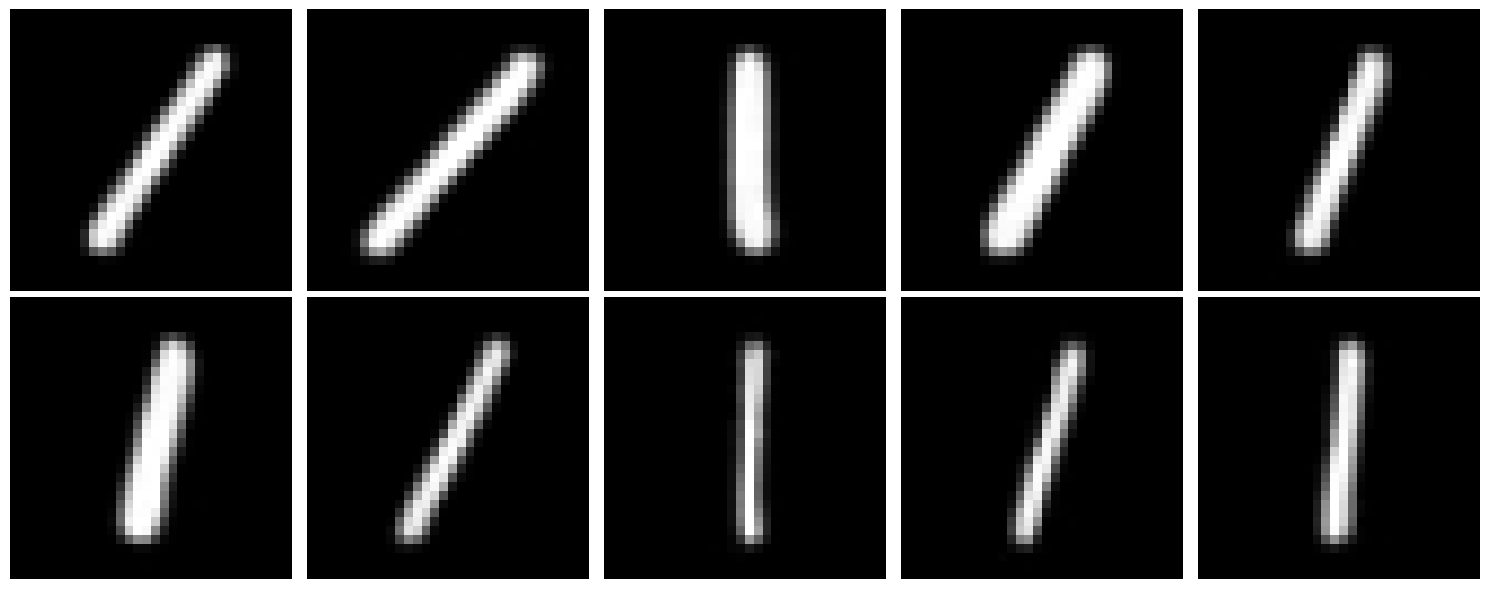

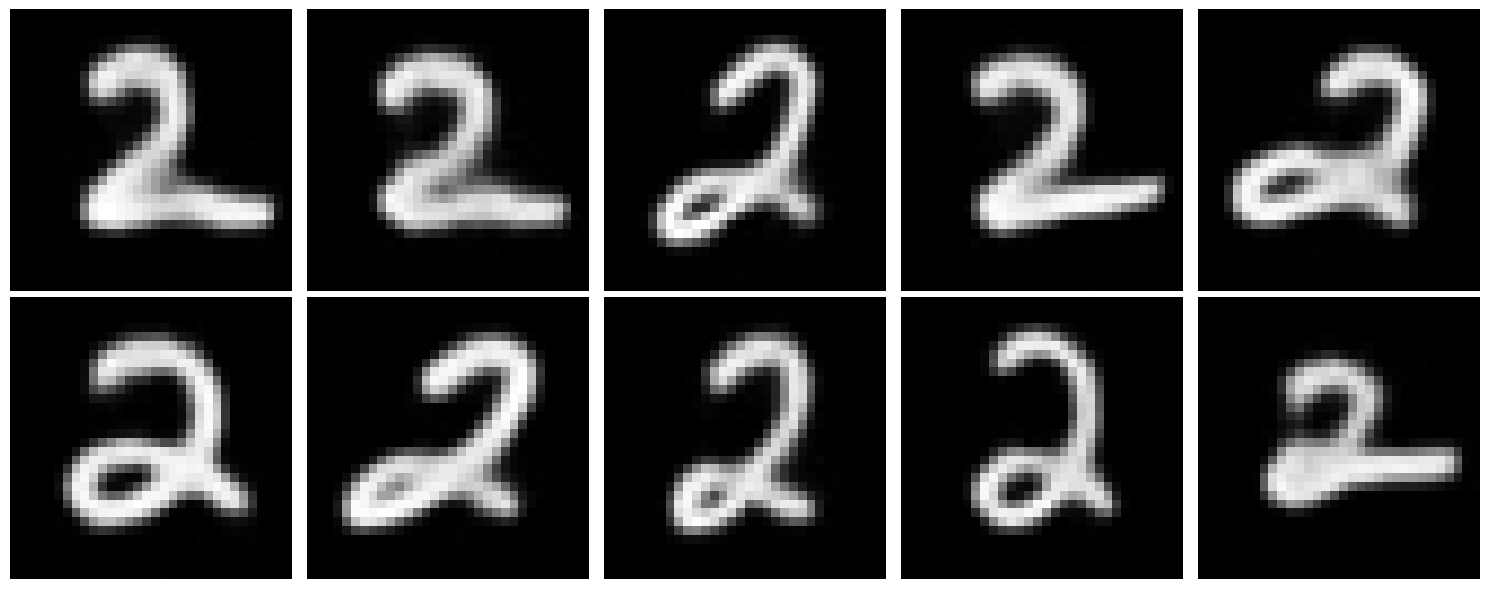

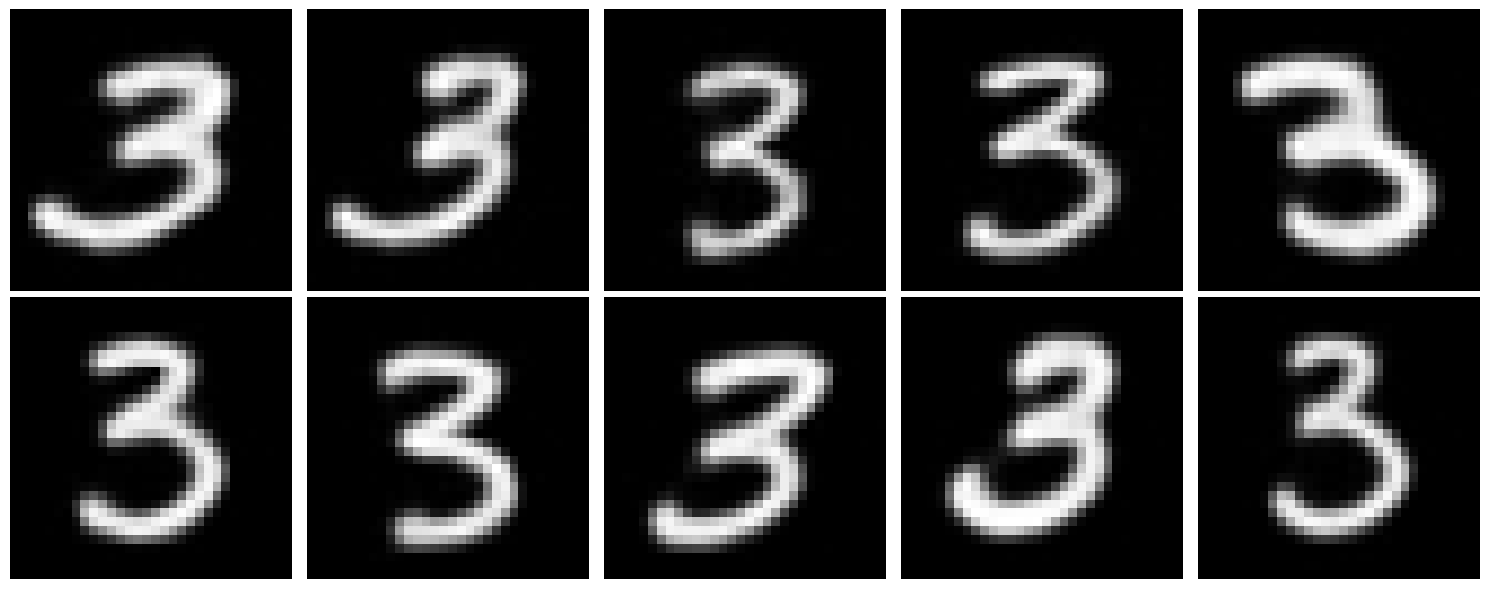

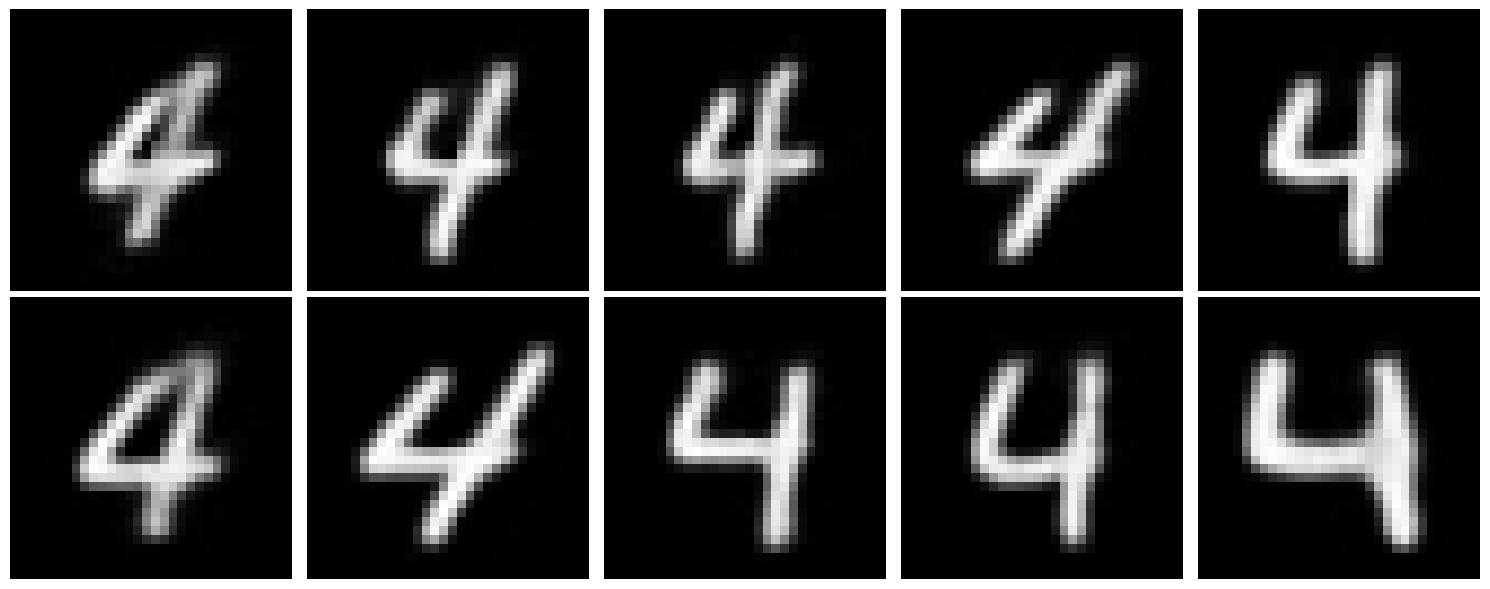

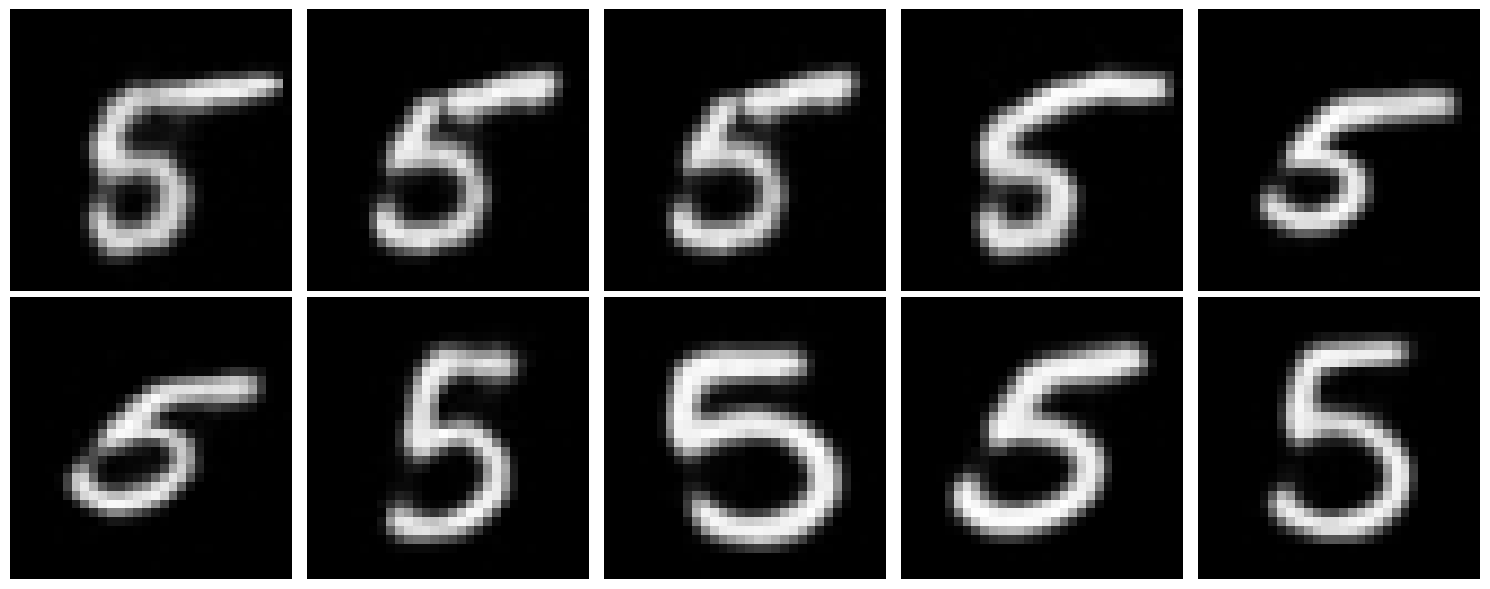

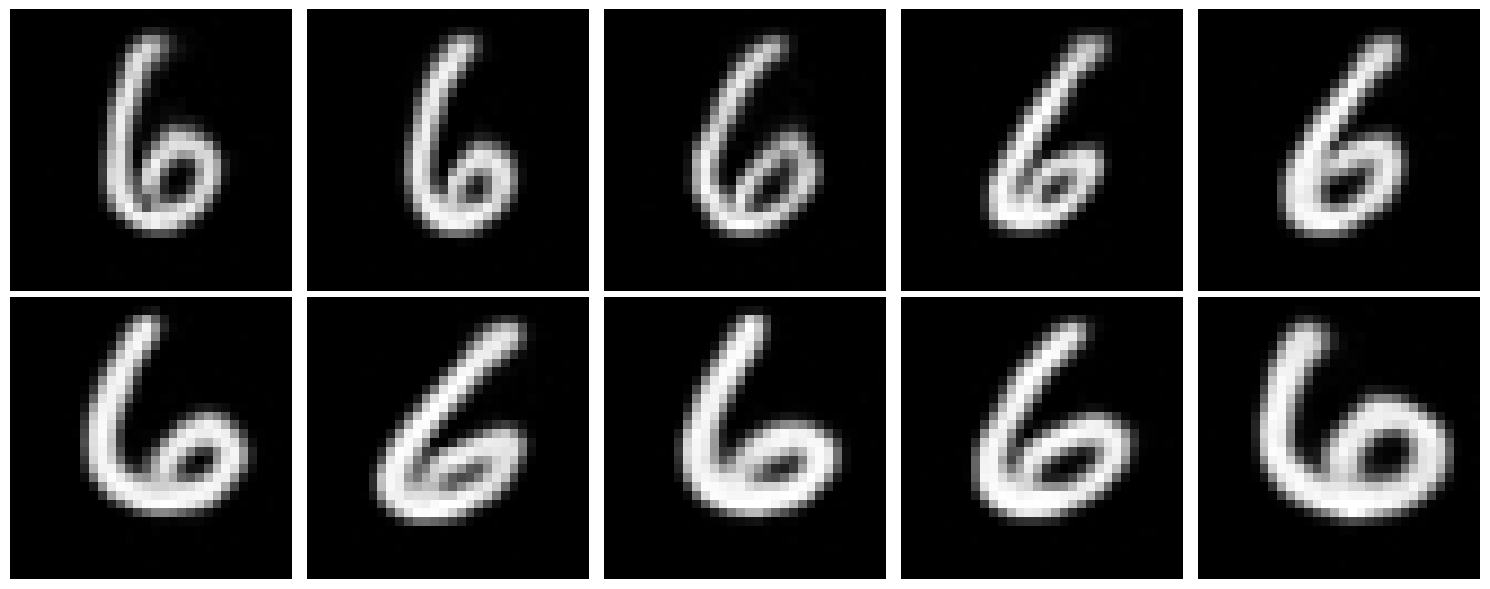

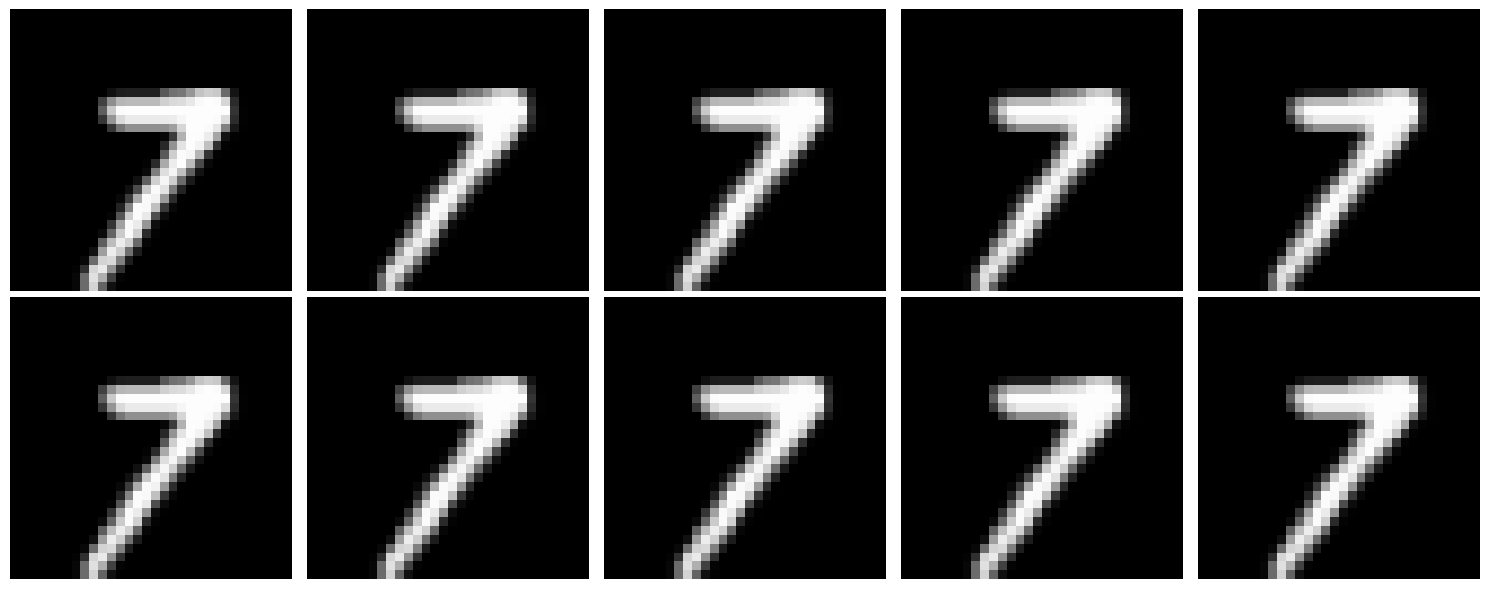

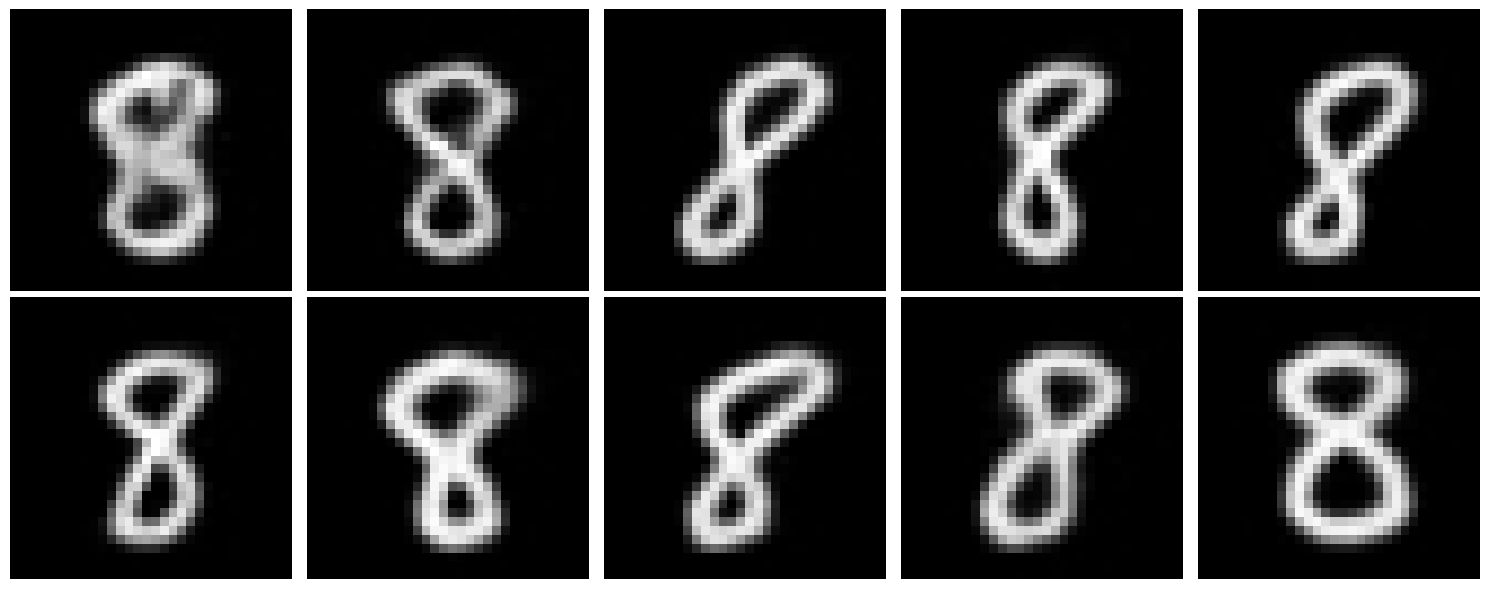

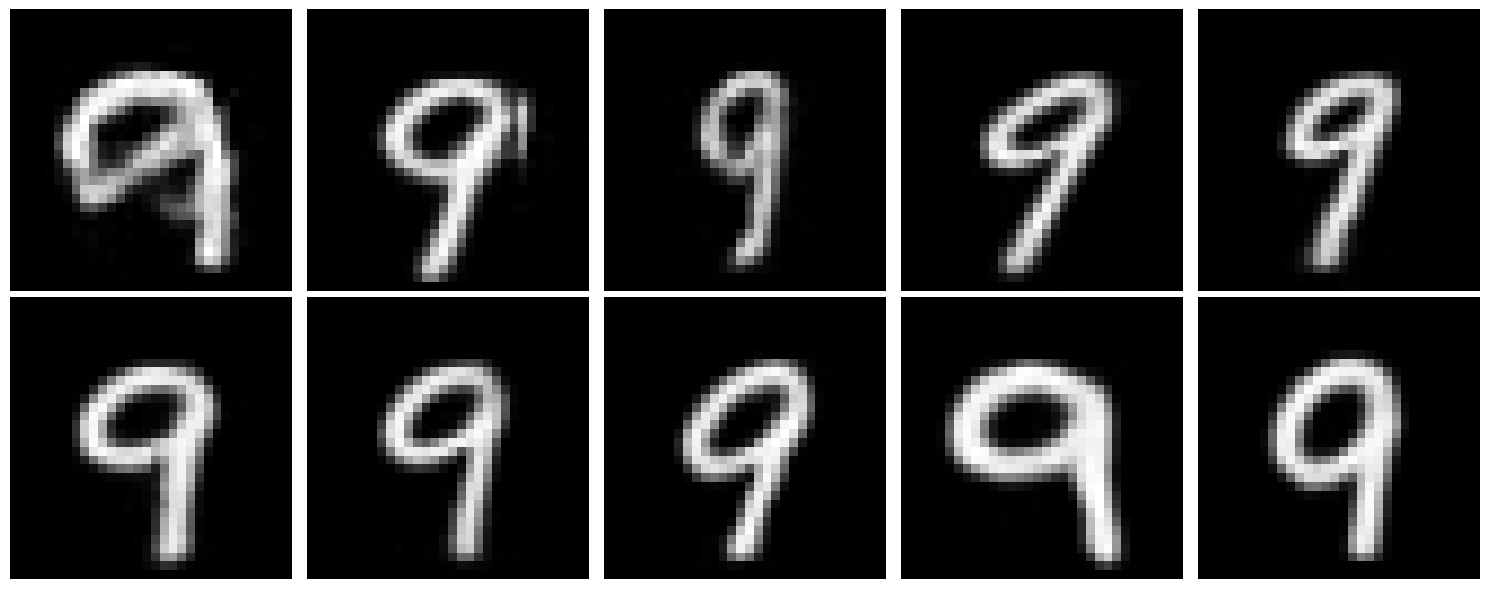

In [30]:
# visualize cluster centers in image space by applying inverse of phi to cluster centers in phi space
with torch.no_grad():
    image_cluster_centers_supervised = phi.inverse(supervised_trainer.cluster_centers.reshape(-1, *phi_data_train.shape[1:]).to(device)).cpu()
    image_cluster_archetypes_supervised = phi.inverse(supervised_trainer.archetypes.reshape(-1, *phi_data_train.shape[1:]).to(device)).cpu()

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()
for i in range(10):
    axes[i].imshow(image_cluster_centers_supervised[i].squeeze(), cmap='gray', vmin=data.min(), vmax=data.max())
    axes[i].axis('off') 
plt.tight_layout()
plt.savefig(os.path.join(results_folder,"barycentres_phi_supervised.png"))
plt.show()

for k in range(10):
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.flatten()
    for i in range(10):
        axes[i].imshow(image_cluster_archetypes_supervised[10*k + i].squeeze(), cmap='gray', vmin=data.min(), vmax=data.max())
        axes[i].axis('off') 
    plt.tight_layout()
    plt.savefig(os.path.join(results_folder,f"archetype_{k}_phi_supervised.png"))
    plt.show()

In [23]:
star_supervised = supervised_trainer.star

chi_supervised = StarImageDiffeomorphism(1, H, W, star_supervised).to(device)
Omega_supervised = ImageCompositionDiffeomorphism([phi, chi_supervised, ConcaveImageDiffeomorphism(1, H, W, LogConcave(a=10.))], 1, H, W)

In [24]:
# construct pullback manifold
Omega_supervised_manifold = StandardPullbackImageEuclidean(Omega_supervised)
iso_Omega_supervised_manifold = l2IsometrizedImageEuclidean(Omega_supervised_manifold, num_intervals=20)

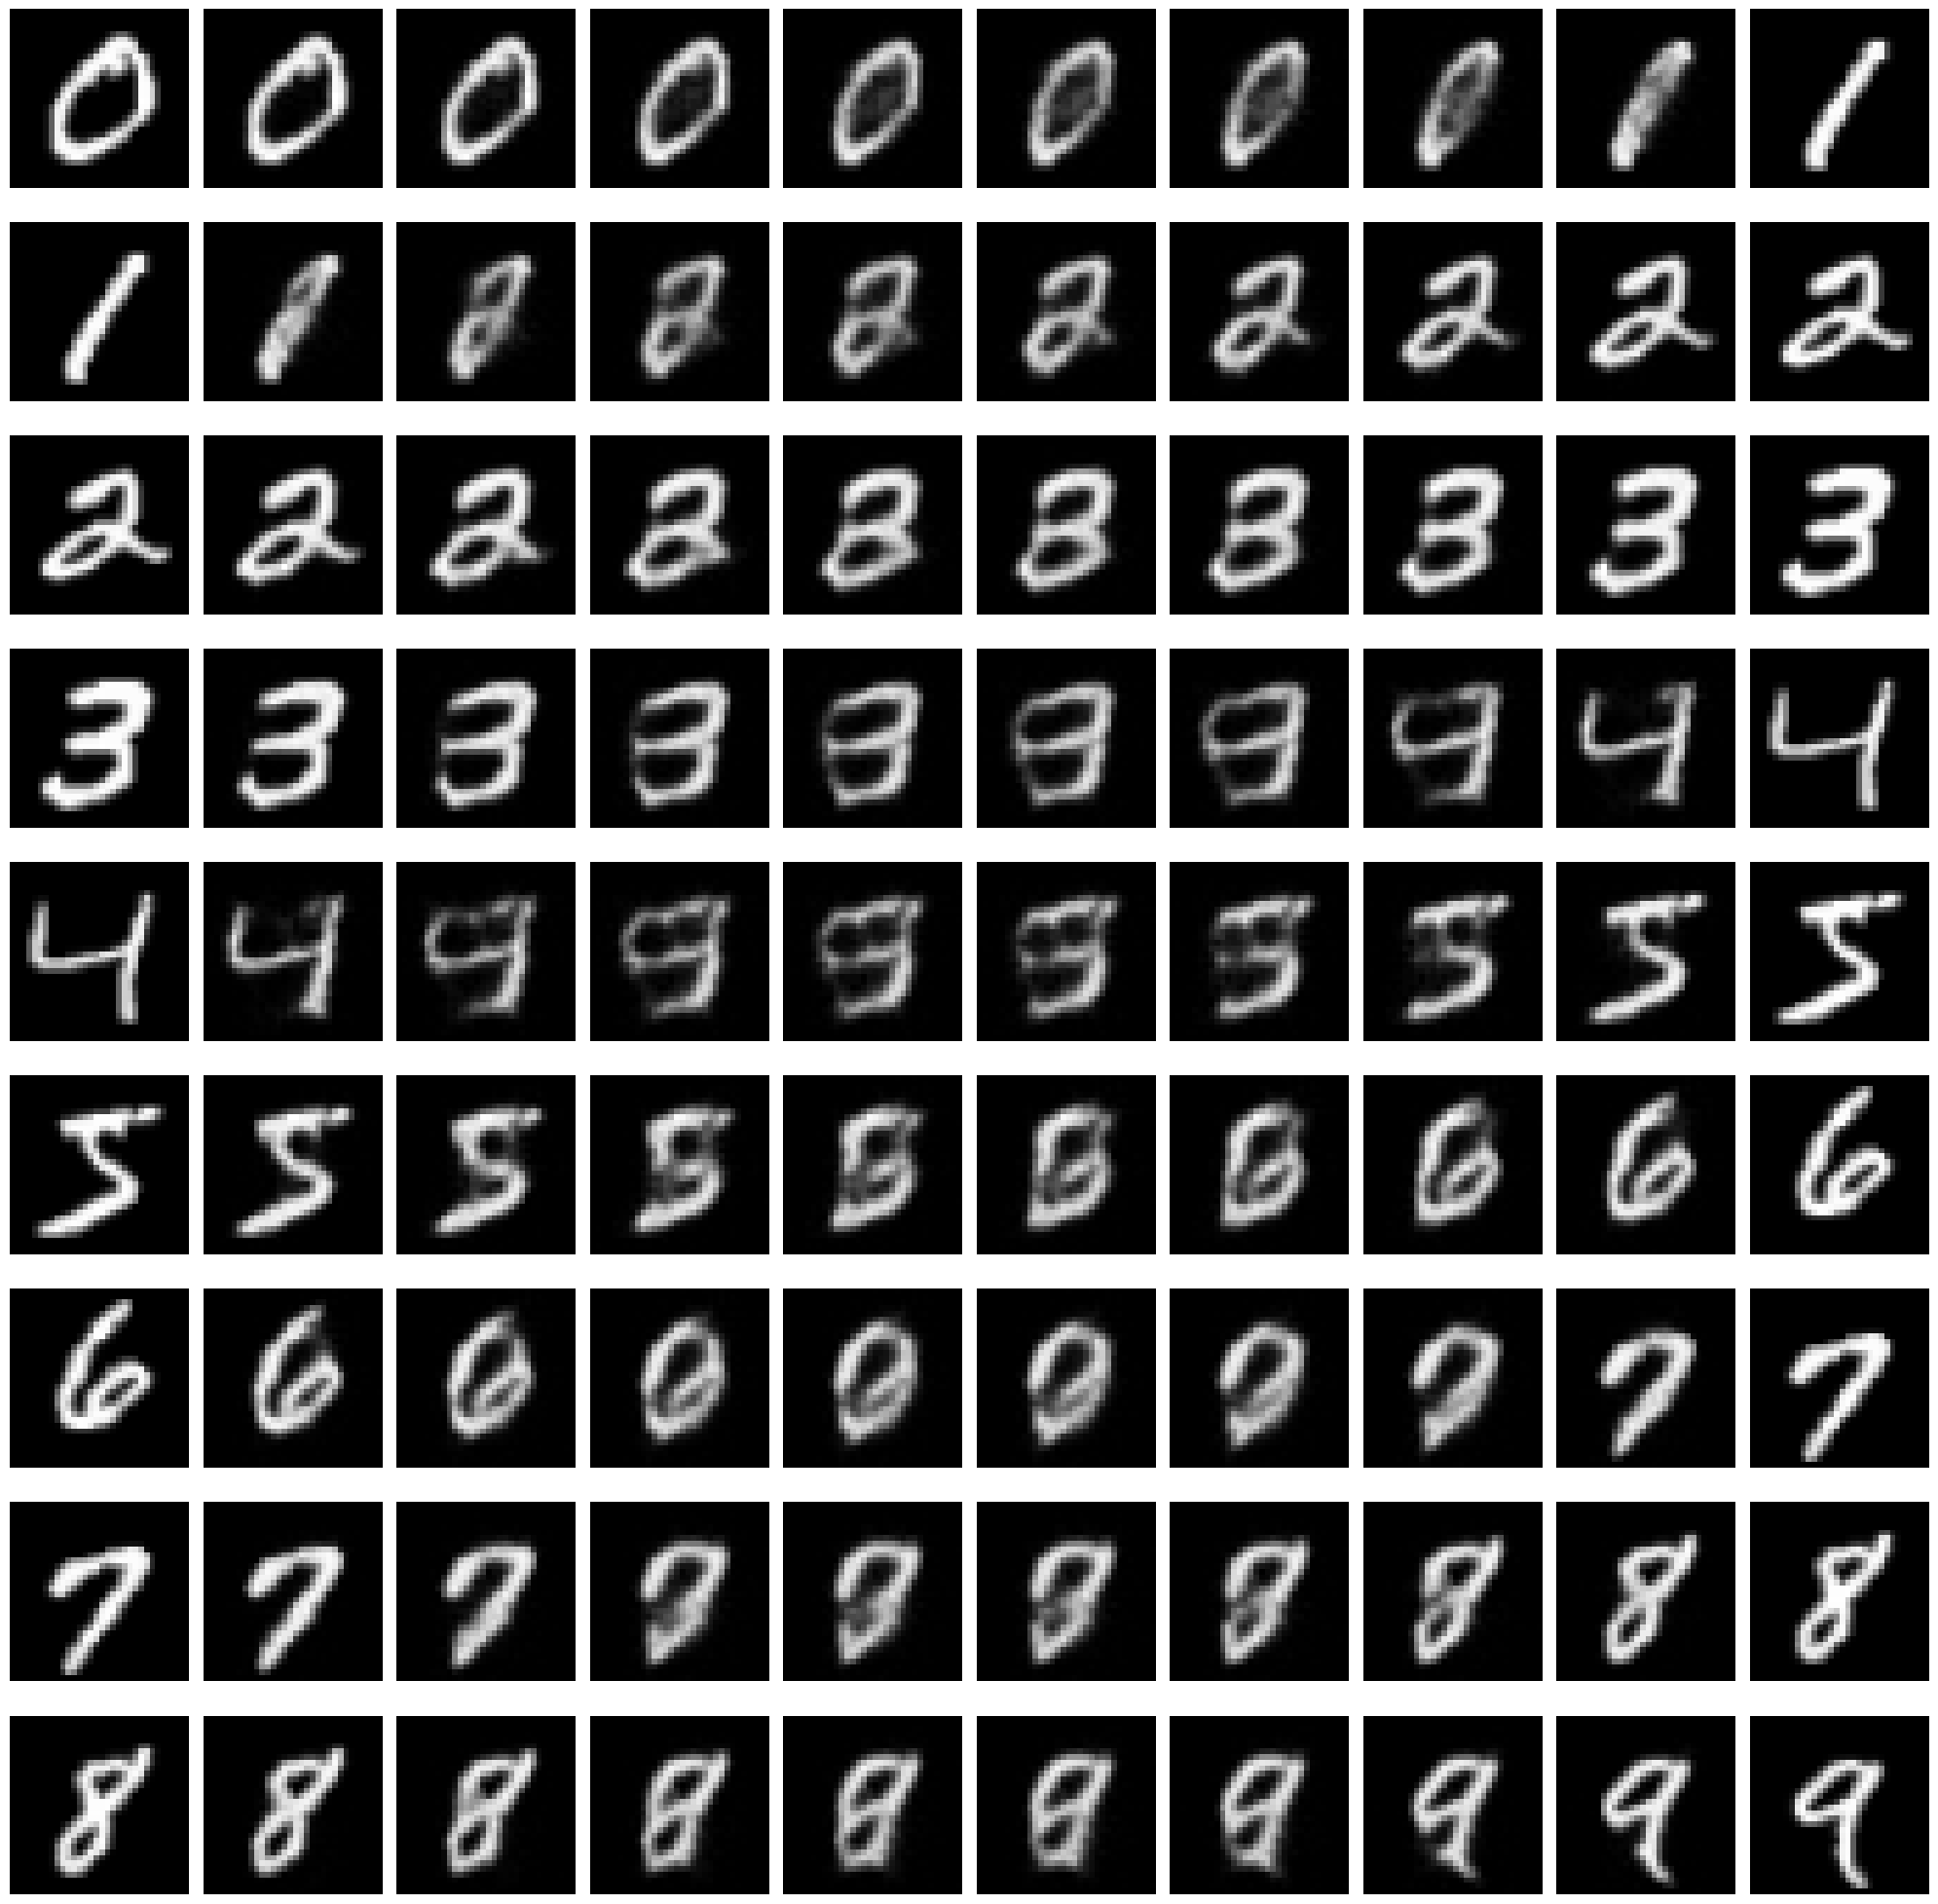

In [25]:
# compute geodesics between all pairs of points
steps = 10
t = torch.linspace(0, 1, steps=steps)
with torch.no_grad():
    Omega_supervised_geodesics = Omega_supervised_manifold.geodesic(data_clusters[None].to(device), data_clusters[None].to(device), t.to(device))[0].cpu() 

# plot geodesics
fig, axes = plt.subplots(9, steps, figsize=(int(steps / 10 * 20), 20))
axes = axes.flatten()
for i in range(10-1):
    for k in range(steps):
        axes[i*steps + k].imshow(Omega_supervised_geodesics[i, i+1, k, 0], cmap='gray', vmin=data.min(), vmax=data.max())
        axes[i*steps + k].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(results_folder,"geodesics_Omega_supervised.png"))
plt.show()

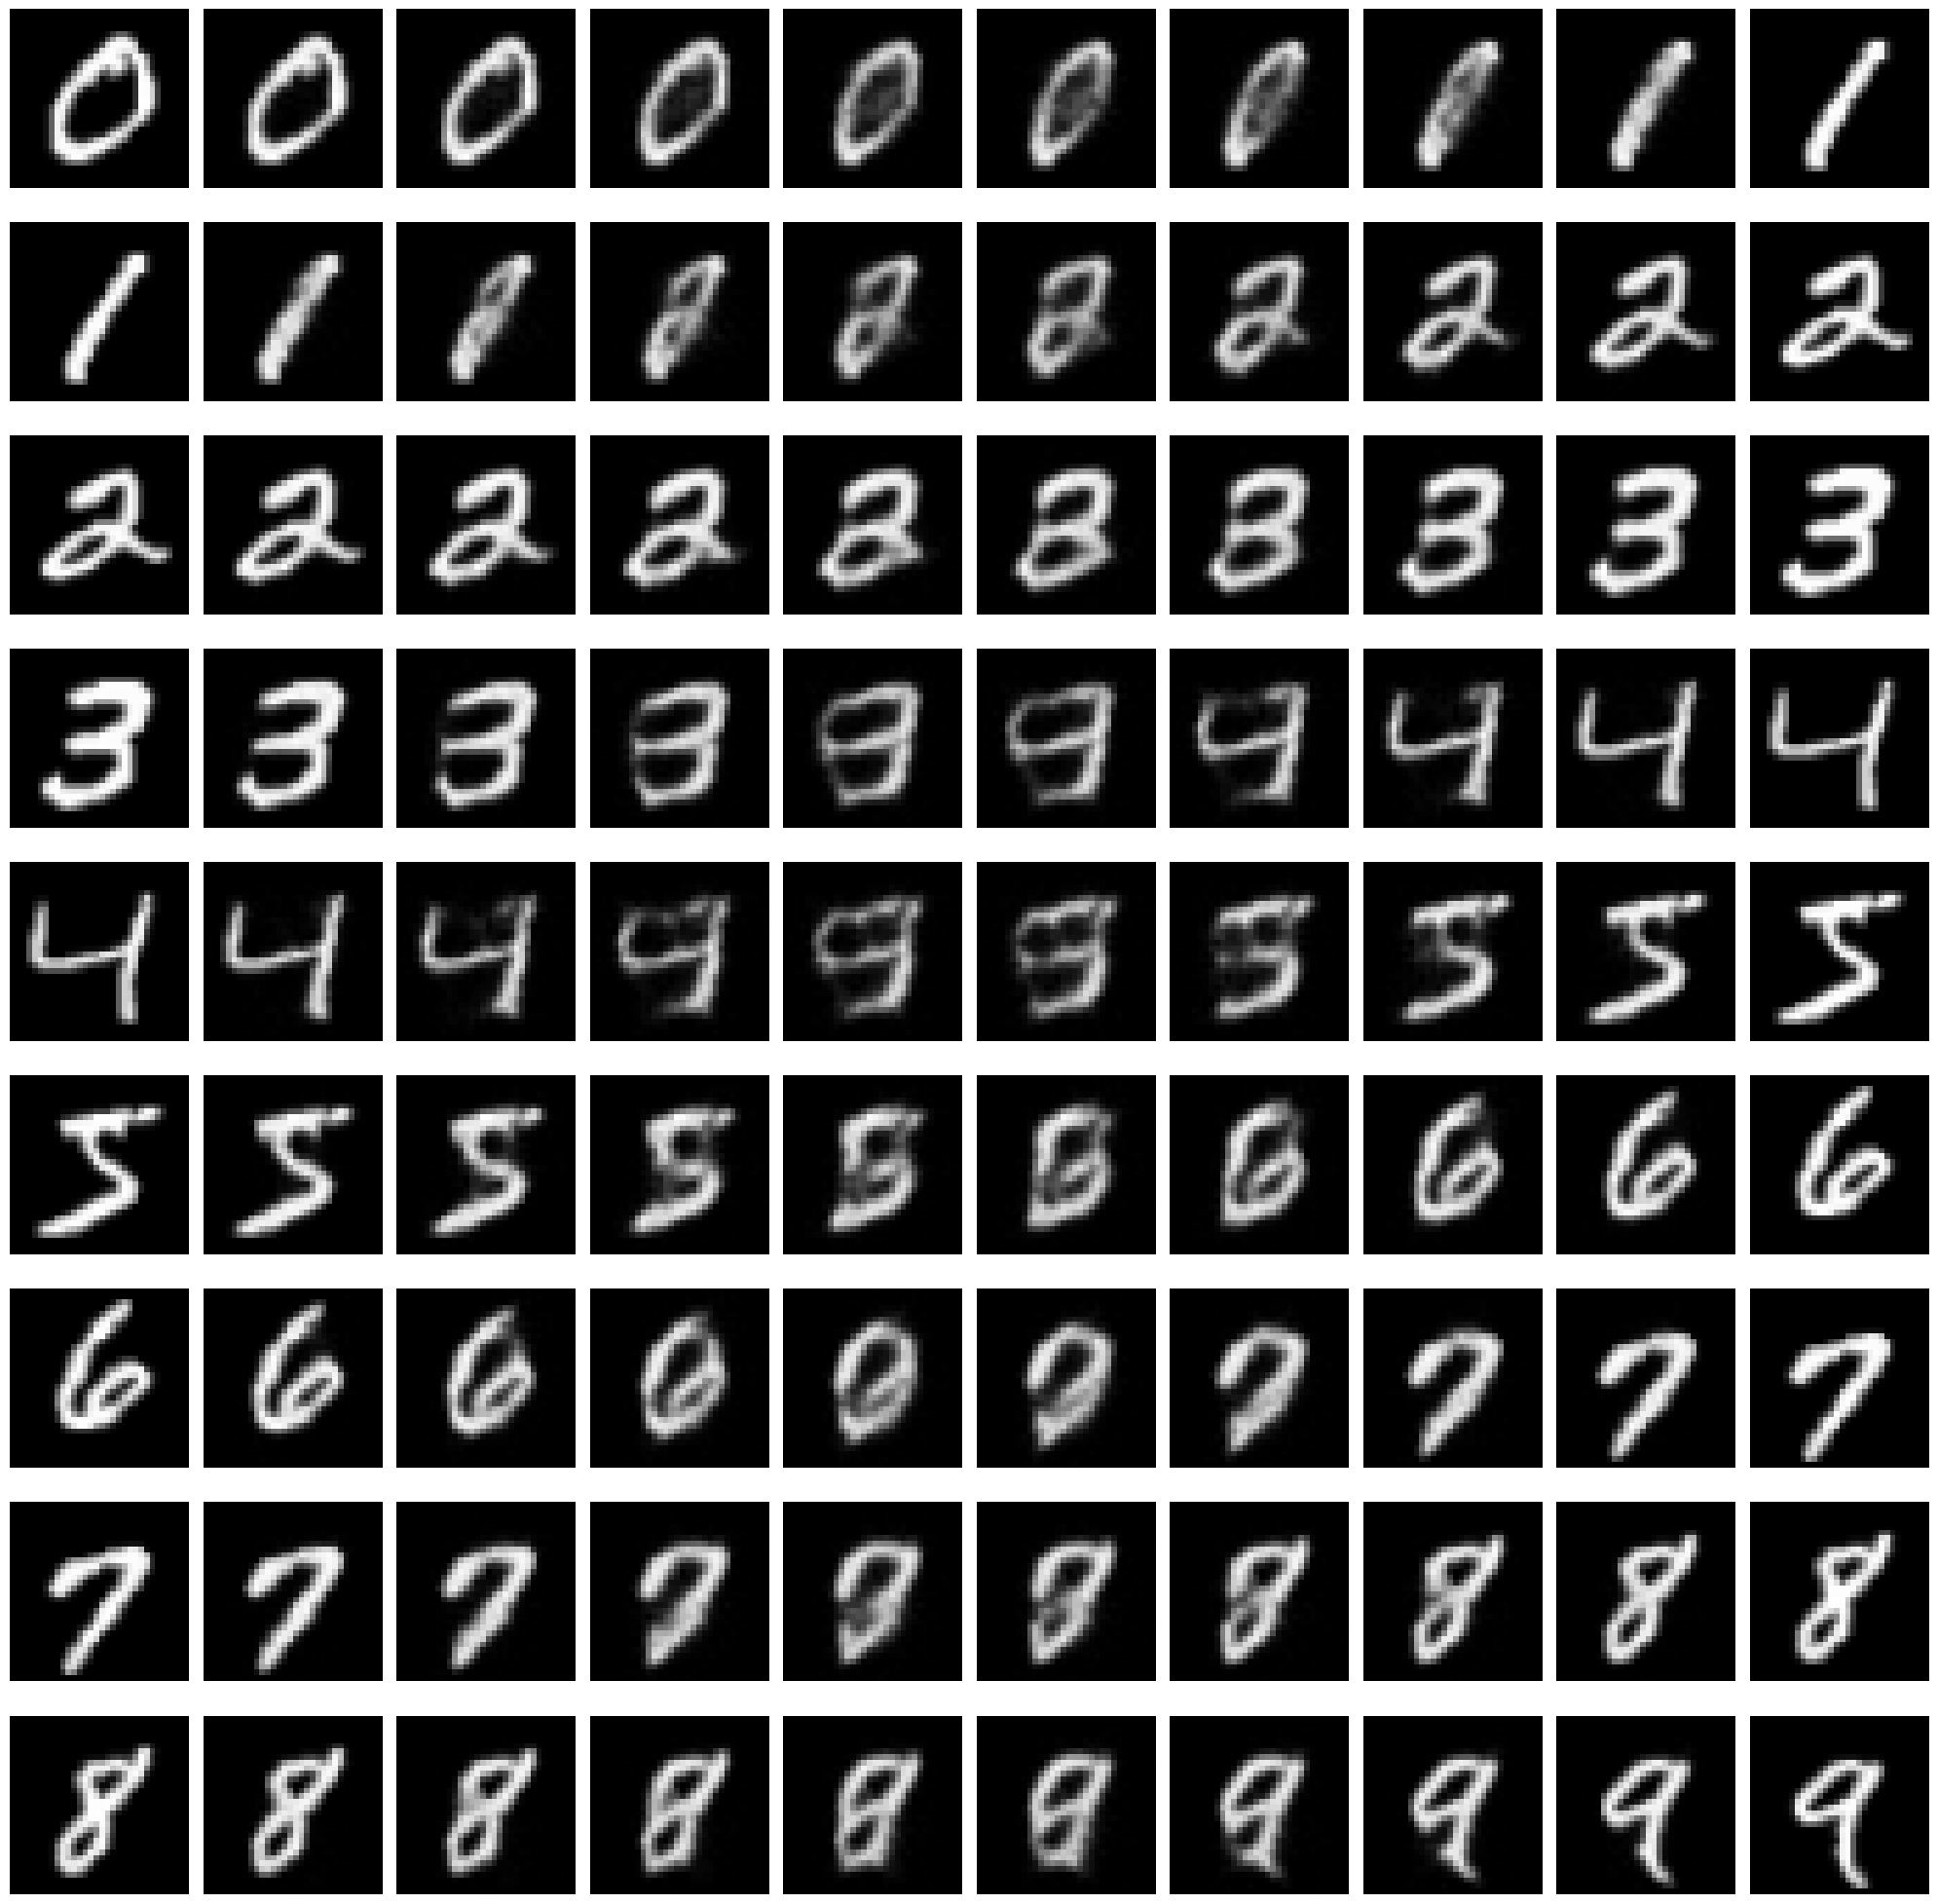

In [26]:
# compute iso geodesics between all pairs of points
with torch.no_grad():
    iso_Omega_supervised_geodesics = iso_Omega_supervised_manifold.geodesic(data_clusters[None].to(device), data_clusters[None].to(device), t.to(device))[0].cpu()

# plot iso-geodesics
fig, axes = plt.subplots(9, steps, figsize=(int(steps / 10 * 20), 20))
axes = axes.flatten()
for i in range(10-1):
    for k in range(steps):
        axes[i*steps + k].imshow(iso_Omega_supervised_geodesics[i, i+1, k, 0], cmap='gray', vmin=data.min(), vmax=data.max())
        axes[i*steps + k].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(results_folder,"geodesics_Omega_supervised_iso.png"))
plt.show()

In [34]:
# construct RAM
ram_supervised = RiemannianArchetypalMapping(Omega_supervised_manifold, image_cluster_archetypes_supervised)

In [35]:
# project clusters
with torch.no_grad():
    ram_supervised_projected_data_clusters = ram_supervised.forward(data_clusters.to(device))

Archetypal Analysis solver finished prediction phase after 137 iterations with objective value 29.5067 and relative change 0.00


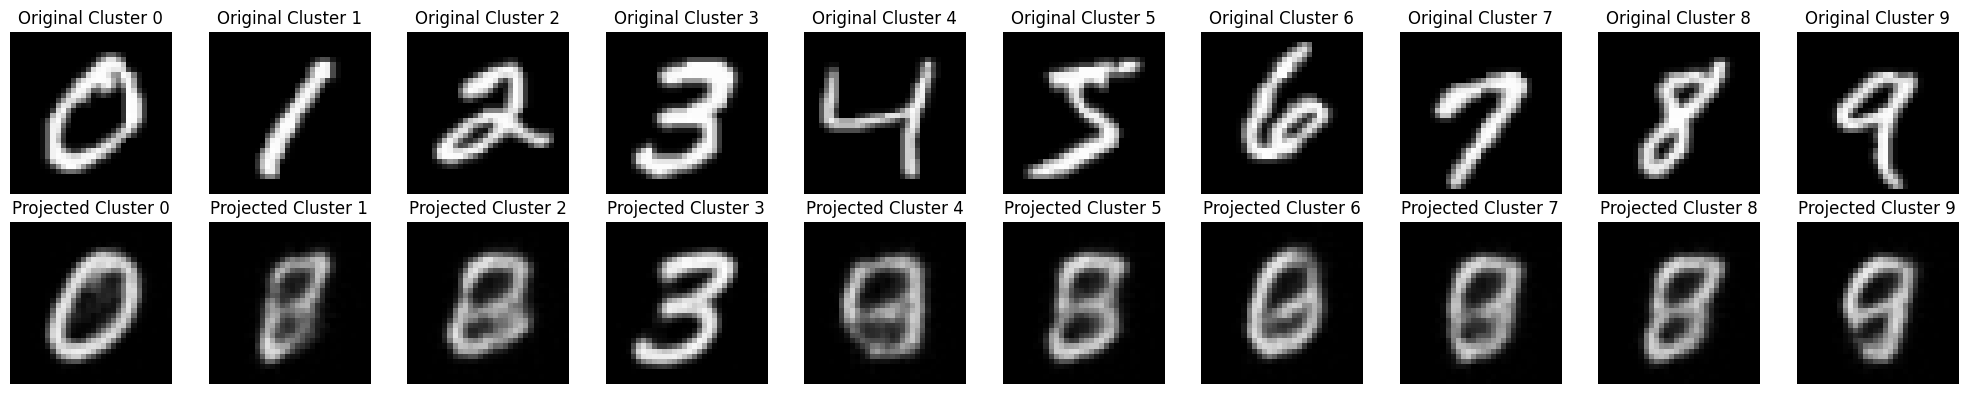

In [36]:
# plot projected clusters next to original clusters
fig, axes = plt.subplots(2, 10, figsize=(20, 4))
for i in range(10):
    axes[0, i].imshow(data_clusters[i].squeeze(), cmap='gray', vmin=data.min(), vmax=data.max())
    axes[0, i].set_title(f"Original Cluster {i}")
    axes[0, i].axis('off')

    axes[1, i].imshow(ram_supervised_projected_data_clusters[i].squeeze(), cmap='gray', vmin=data.min(), vmax=data.max())
    axes[1, i].set_title(f"Projected Cluster {i}")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

### Unsupervised ###

In [ ]:
# archetypal analysis clustering on the logs
N = phi_logs_data_train.shape[0]
AA_solver = ArchetypalAnalysisSolver(H*W, N)

AA_solver.fit(phi_logs_data_train.reshape(N, -1).T, r=starflow_cfg["n_clusters"], N_max=200, max_iter=1000)

tangent_image_AA_end_members_unsupervised = AA_solver.V.T.reshape(-1, 1, H, W)
with torch.no_grad():
    image_cluster_AA_end_members_unsupervised = phi_manifold.exp(phi_barycentre, tangent_image_AA_end_members_unsupervised[None].to(device)).cpu()[0]
    phi_end_members_unsupervised = phi(image_cluster_AA_end_members_unsupervised.to(device)).cpu()

labels_unsupervised = AA_solver.labels

Archetypal Analysis solver finished fitting phase after 461 iterations with objective value 89040.1523 and relative change 0.00
Archetypal Analysis solver finished prediction phase after 113 iterations with objective value 37537560.1235 and relative change 0.00


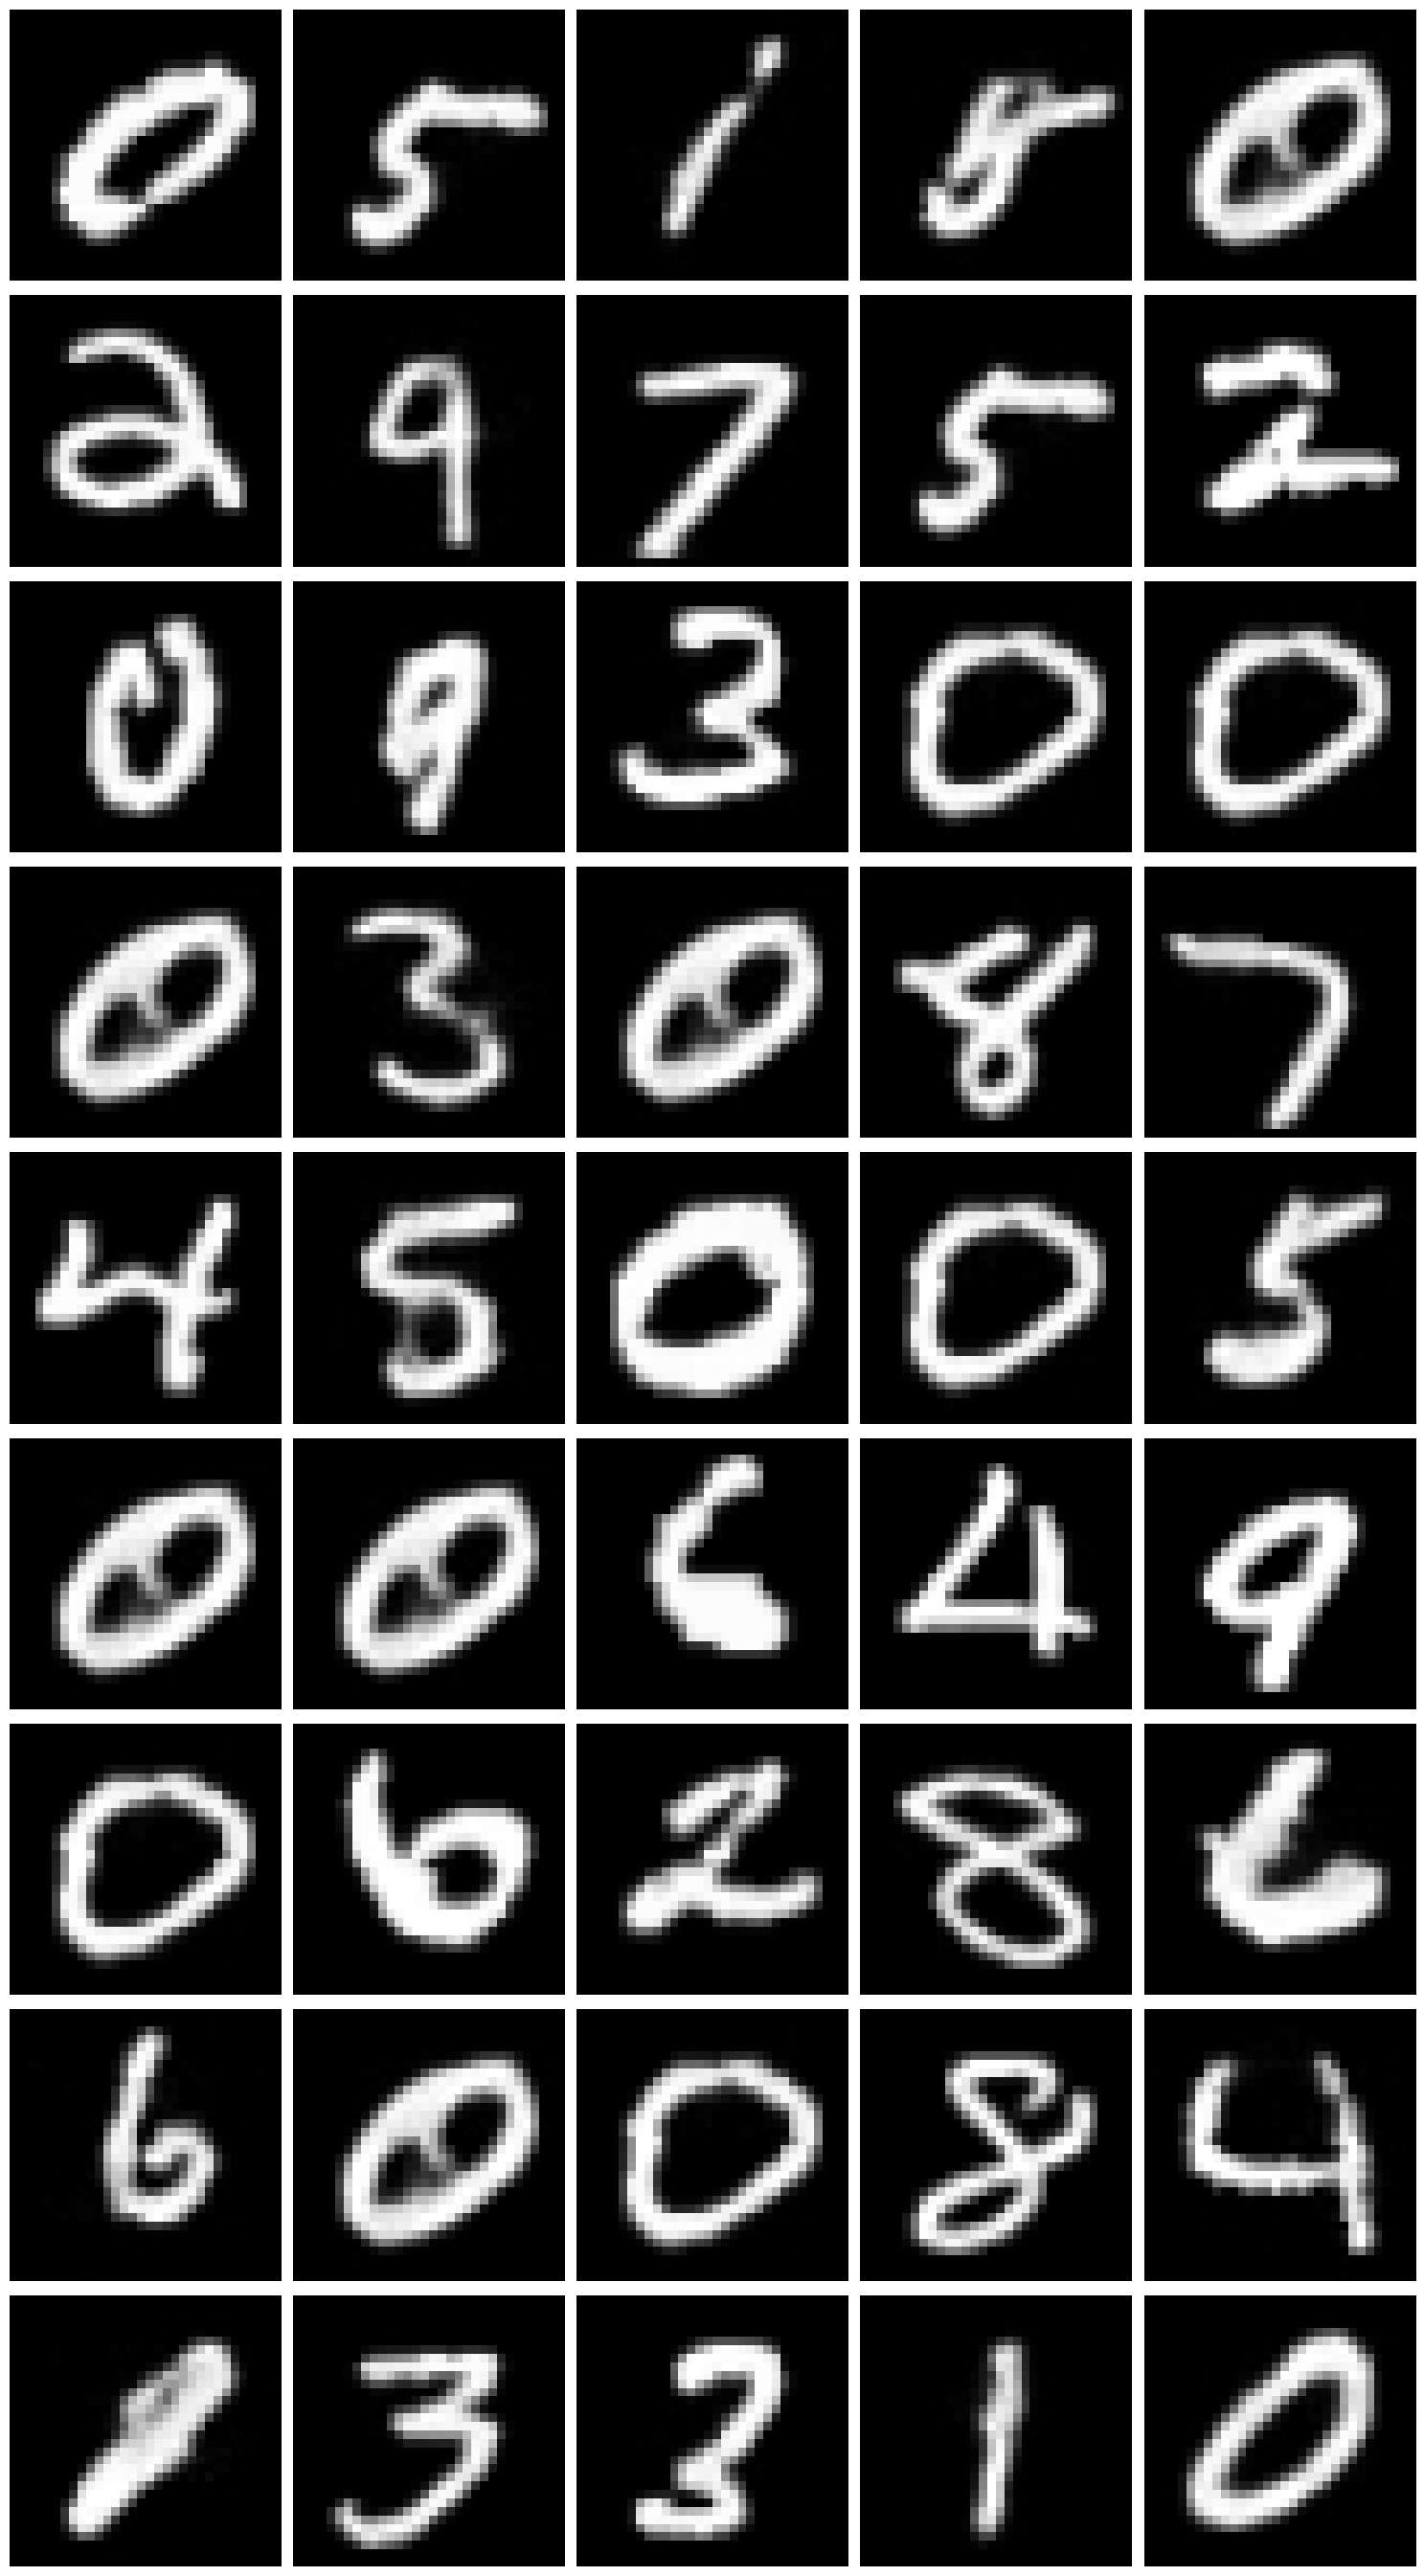

In [ ]:
# plot cluster centers in image space by applying inverse of phi to cluster centers in phi space
num_horizontal = 5
num_vertical = (starflow_cfg["n_clusters"] + num_horizontal - 1) // num_horizontal - 1

fig, axes = plt.subplots(num_vertical, num_horizontal, figsize=(3 * num_horizontal, 3 * num_vertical))
axes = axes.flatten()
for i in range(num_horizontal * num_vertical): 
    axes[i].imshow(image_cluster_AA_end_members_unsupervised[i].squeeze(), cmap='gray', vmin=data.min(), vmax=data.max())
    axes[i].axis('off')
plt.tight_layout()
plt.savefig(os.path.join(results_folder,"end_members_AA_phi_unsupervised.png"))
plt.show()

In [ ]:
unsupervised_trainer = StarConstruction([1, H, W], trimmed=True)

In [ ]:
unsupervised_trainer.fit(phi_data_train, labels=labels_unsupervised, min_cluster_size=50)
# unsupervised_trainer.fit(phi_data_train, labels=labels_unsupervised, end_members=phi_end_members_unsupervised)

Cluster 3 has size 2 which is less than minimum cluster size 50. Skipping this cluster.
Cluster 4 has size 0 which is less than minimum cluster size 50. Skipping this cluster.
Cluster 7 has size 0 which is less than minimum cluster size 50. Skipping this cluster.
Cluster 11 has size 1 which is less than minimum cluster size 50. Skipping this cluster.
Cluster 13 has size 0 which is less than minimum cluster size 50. Skipping this cluster.
Cluster 19 has size 0 which is less than minimum cluster size 50. Skipping this cluster.
Cluster 20 has size 0 which is less than minimum cluster size 50. Skipping this cluster.
Cluster 35 has size 0 which is less than minimum cluster size 50. Skipping this cluster.
Cluster 36 has size 0 which is less than minimum cluster size 50. Skipping this cluster.


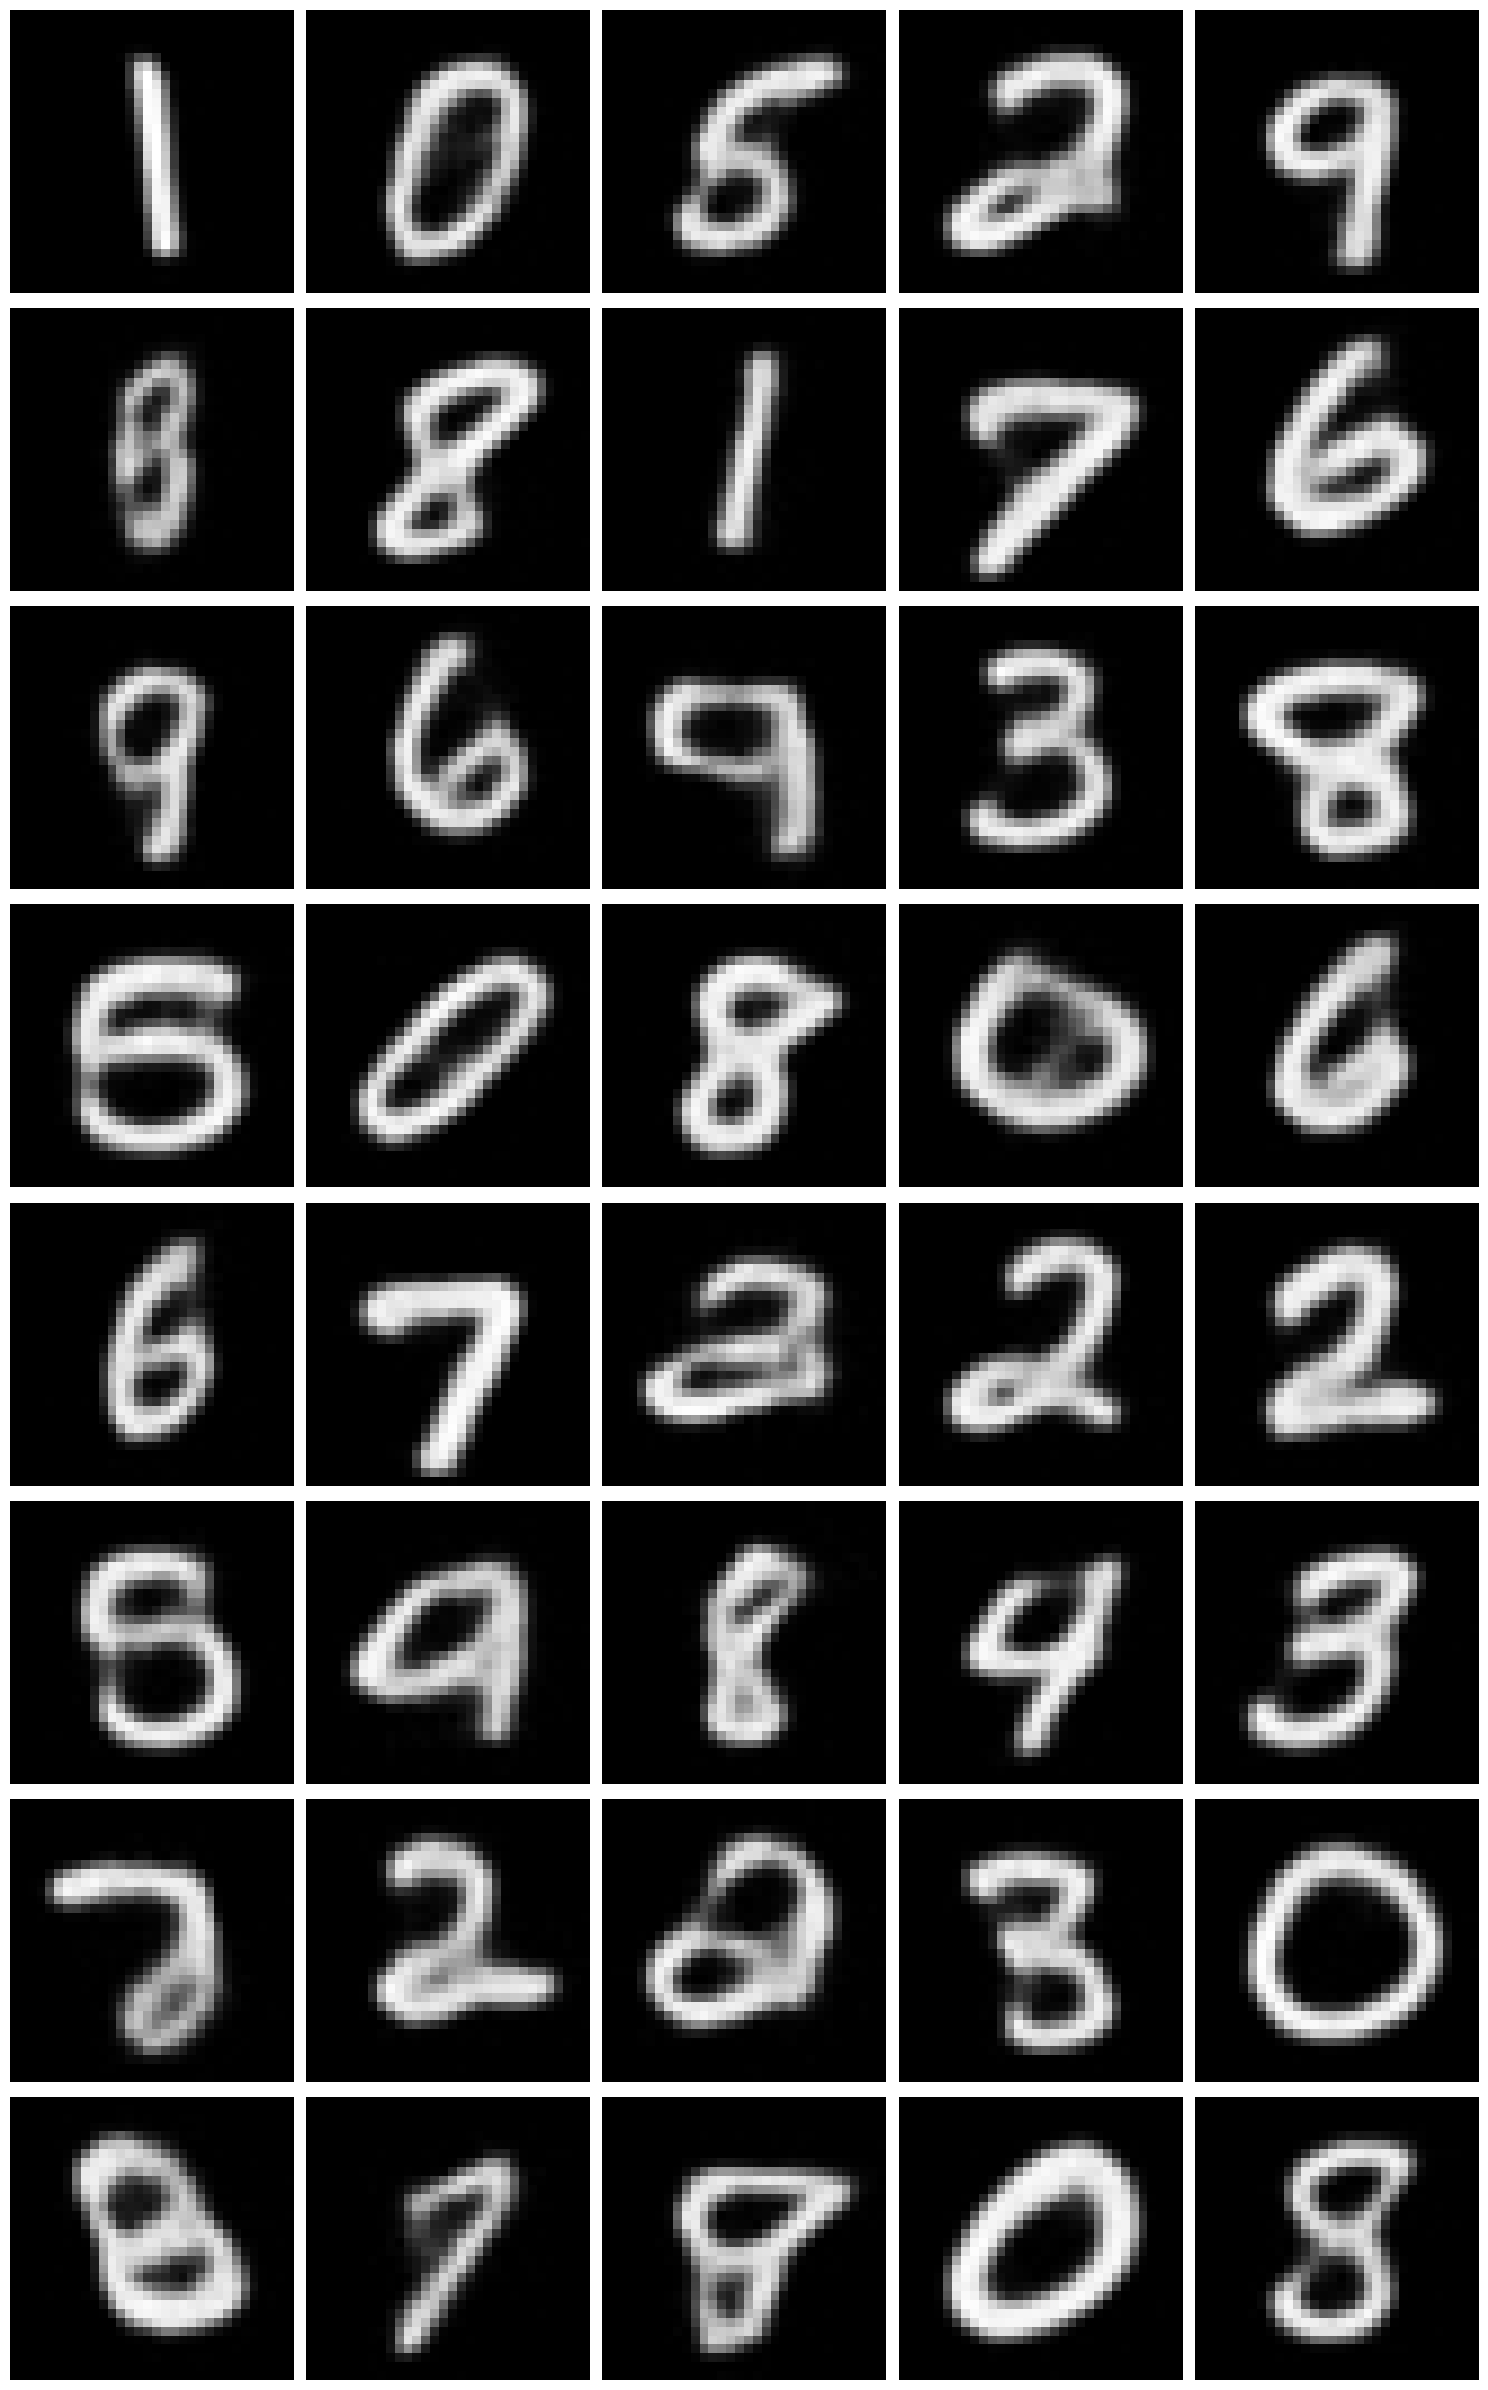

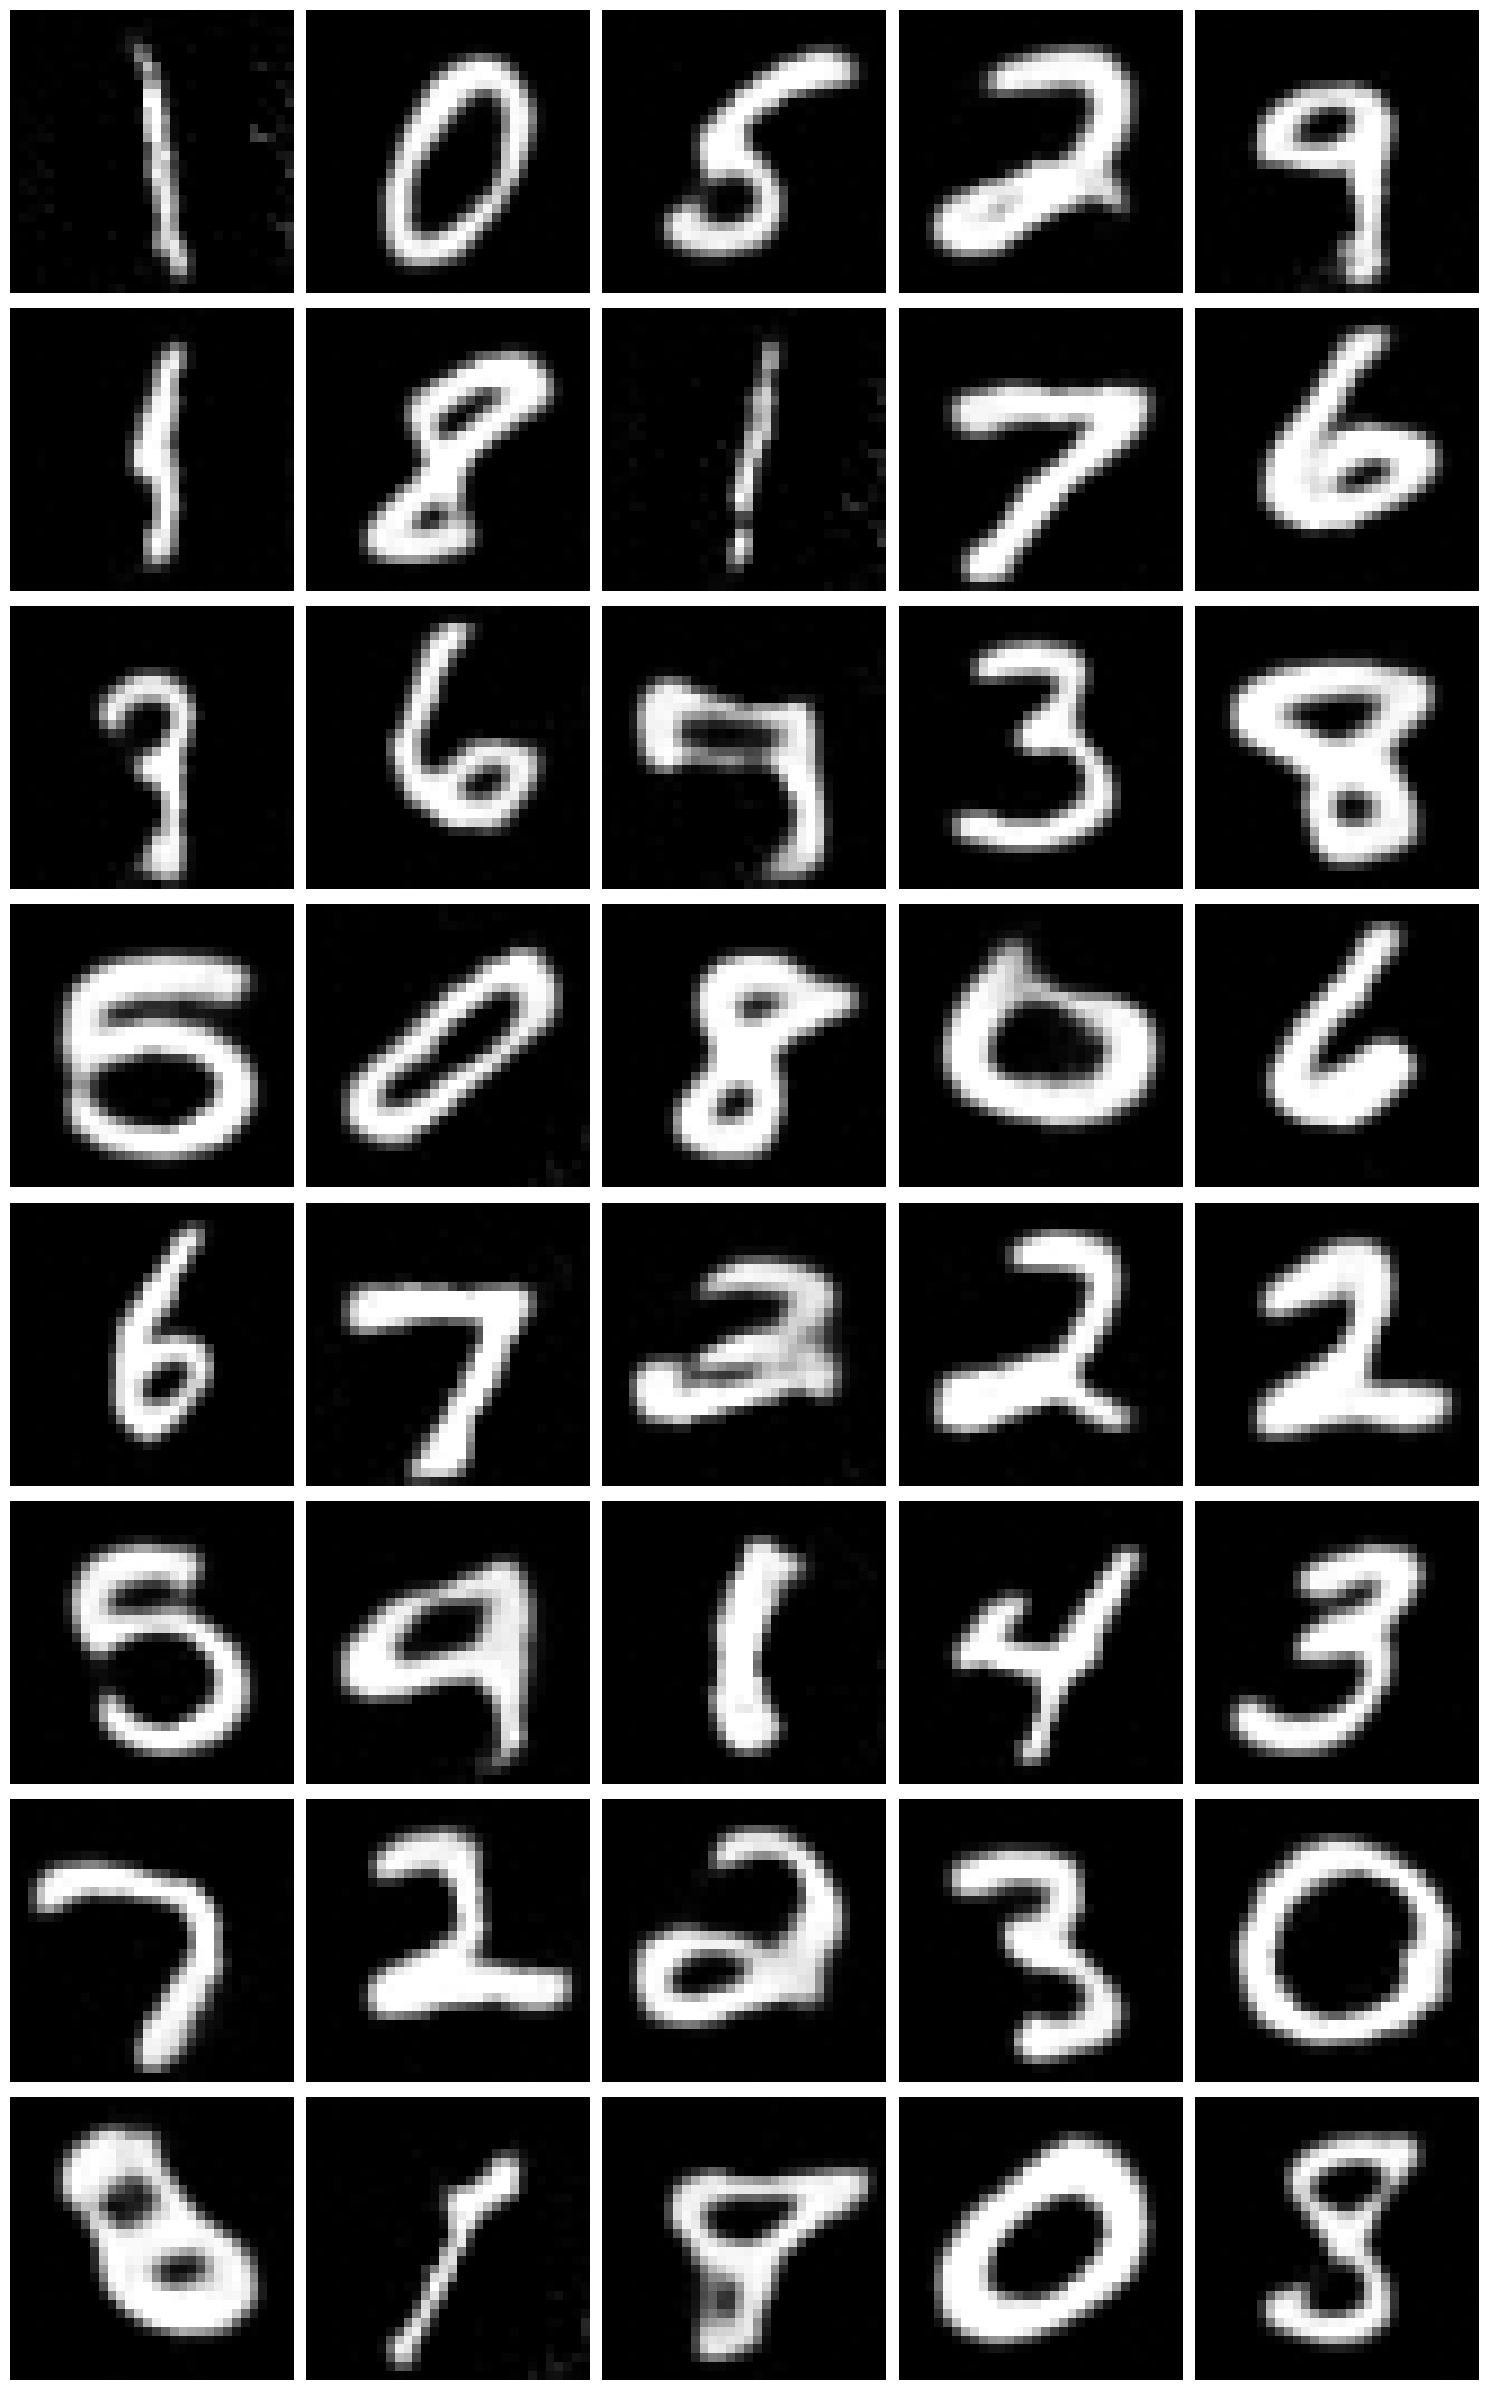

In [ ]:
# plot cluster centers in image space by applying inverse of phi to cluster centers in phi space
with torch.no_grad():
    image_cluster_centers_unsupervised = phi.inverse(unsupervised_trainer.cluster_centers.to(device)).cpu()
    image_cluster_end_members_unsupervised = phi.inverse(unsupervised_trainer.cluster_end_members.to(device)).cpu()

num_vertical = (unsupervised_trainer.k + num_horizontal - 1) // num_horizontal - 1

fig, axes = plt.subplots(num_vertical, num_horizontal, figsize=(3 * num_horizontal, 3 * num_vertical))
axes = axes.flatten()
for i in range(num_horizontal * num_vertical):
    axes[i].imshow(image_cluster_centers_unsupervised[i].squeeze(), cmap='gray', vmin=data.min(), vmax=data.max())
    axes[i].axis('off')
plt.tight_layout()
plt.savefig(os.path.join(results_folder,"barycentres_phi_unsupervised.png"))
plt.show()

fig, axes = plt.subplots(num_vertical, num_horizontal, figsize=(3 * num_horizontal, 3 * num_vertical))
axes = axes.flatten()
for i in range(num_horizontal * num_vertical):
    axes[i].imshow(image_cluster_end_members_unsupervised[i].squeeze(), cmap='gray', vmin=data.min(), vmax=data.max())
    axes[i].axis('off')
plt.tight_layout()
plt.savefig(os.path.join(results_folder,"end_members_phi_unsupervised.png"))
plt.show()

In [ ]:
star_unsupervised = unsupervised_trainer.star

chi_unsupervised = StarImageDiffeomorphism(1, H, W, star_unsupervised).to(device)
Omega_unsupervised = ImageCompositionDiffeomorphism([phi, chi_unsupervised, ConcaveImageDiffeomorphism(1, H, W, LogConcave(a=10.))], 1, H, W)

In [ ]:
Omega_unsupervised_manifold = StandardPullbackImageEuclidean(Omega_unsupervised)

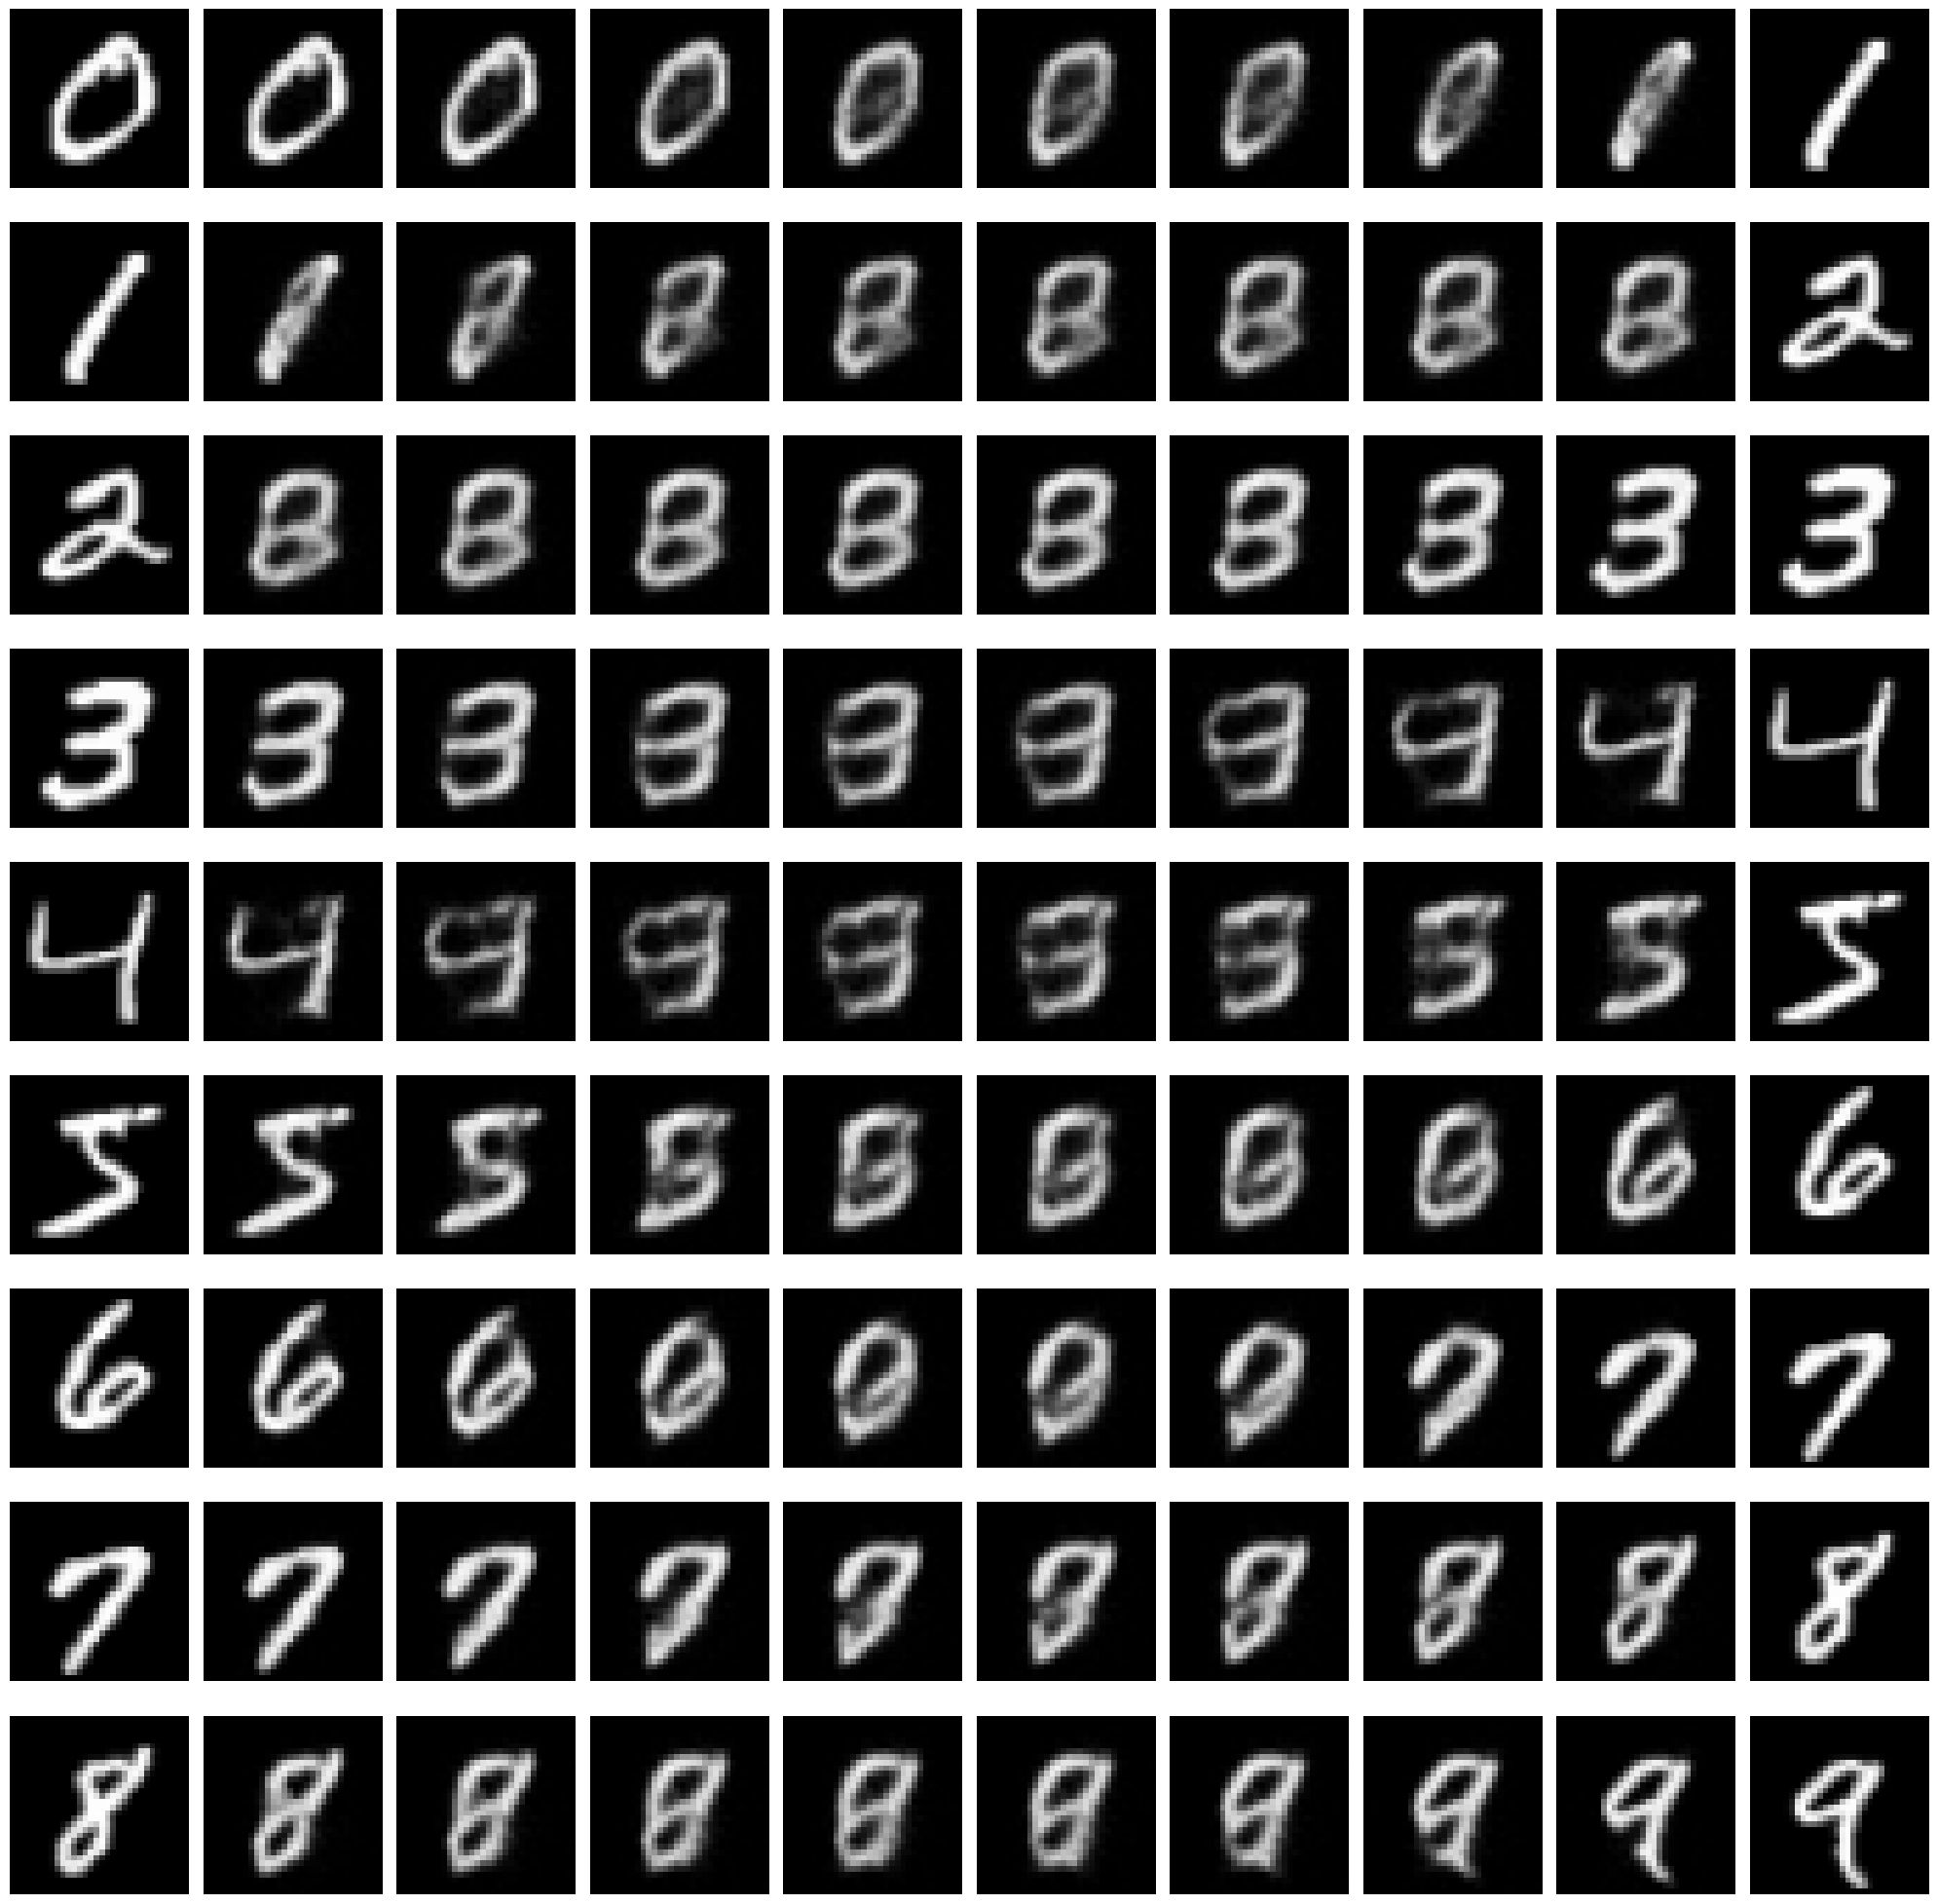

In [ ]:
with torch.no_grad():
    Omega_unsupervised_geodesics = Omega_unsupervised_manifold.geodesic(data_clusters[None].to(device), data_clusters[None].to(device), t.to(device))[0].cpu() 

# plot geodesics
fig, axes = plt.subplots(9, steps, figsize=(int(steps / 10 * 20), 20))
axes = axes.flatten()
for i in range(10-1):
    for k in range(steps):
        axes[i*steps + k].imshow(Omega_unsupervised_geodesics[i, i+1, k, 0], cmap='gray', vmin=data.min(), vmax=data.max())
        axes[i*steps + k].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(results_folder,"geodesics_Omega_unsupervised.png"))
plt.show()

In [ ]:
iso_Omega_unsupervised_manifold = l2IsometrizedImageEuclidean(Omega_unsupervised_manifold, num_intervals=20)

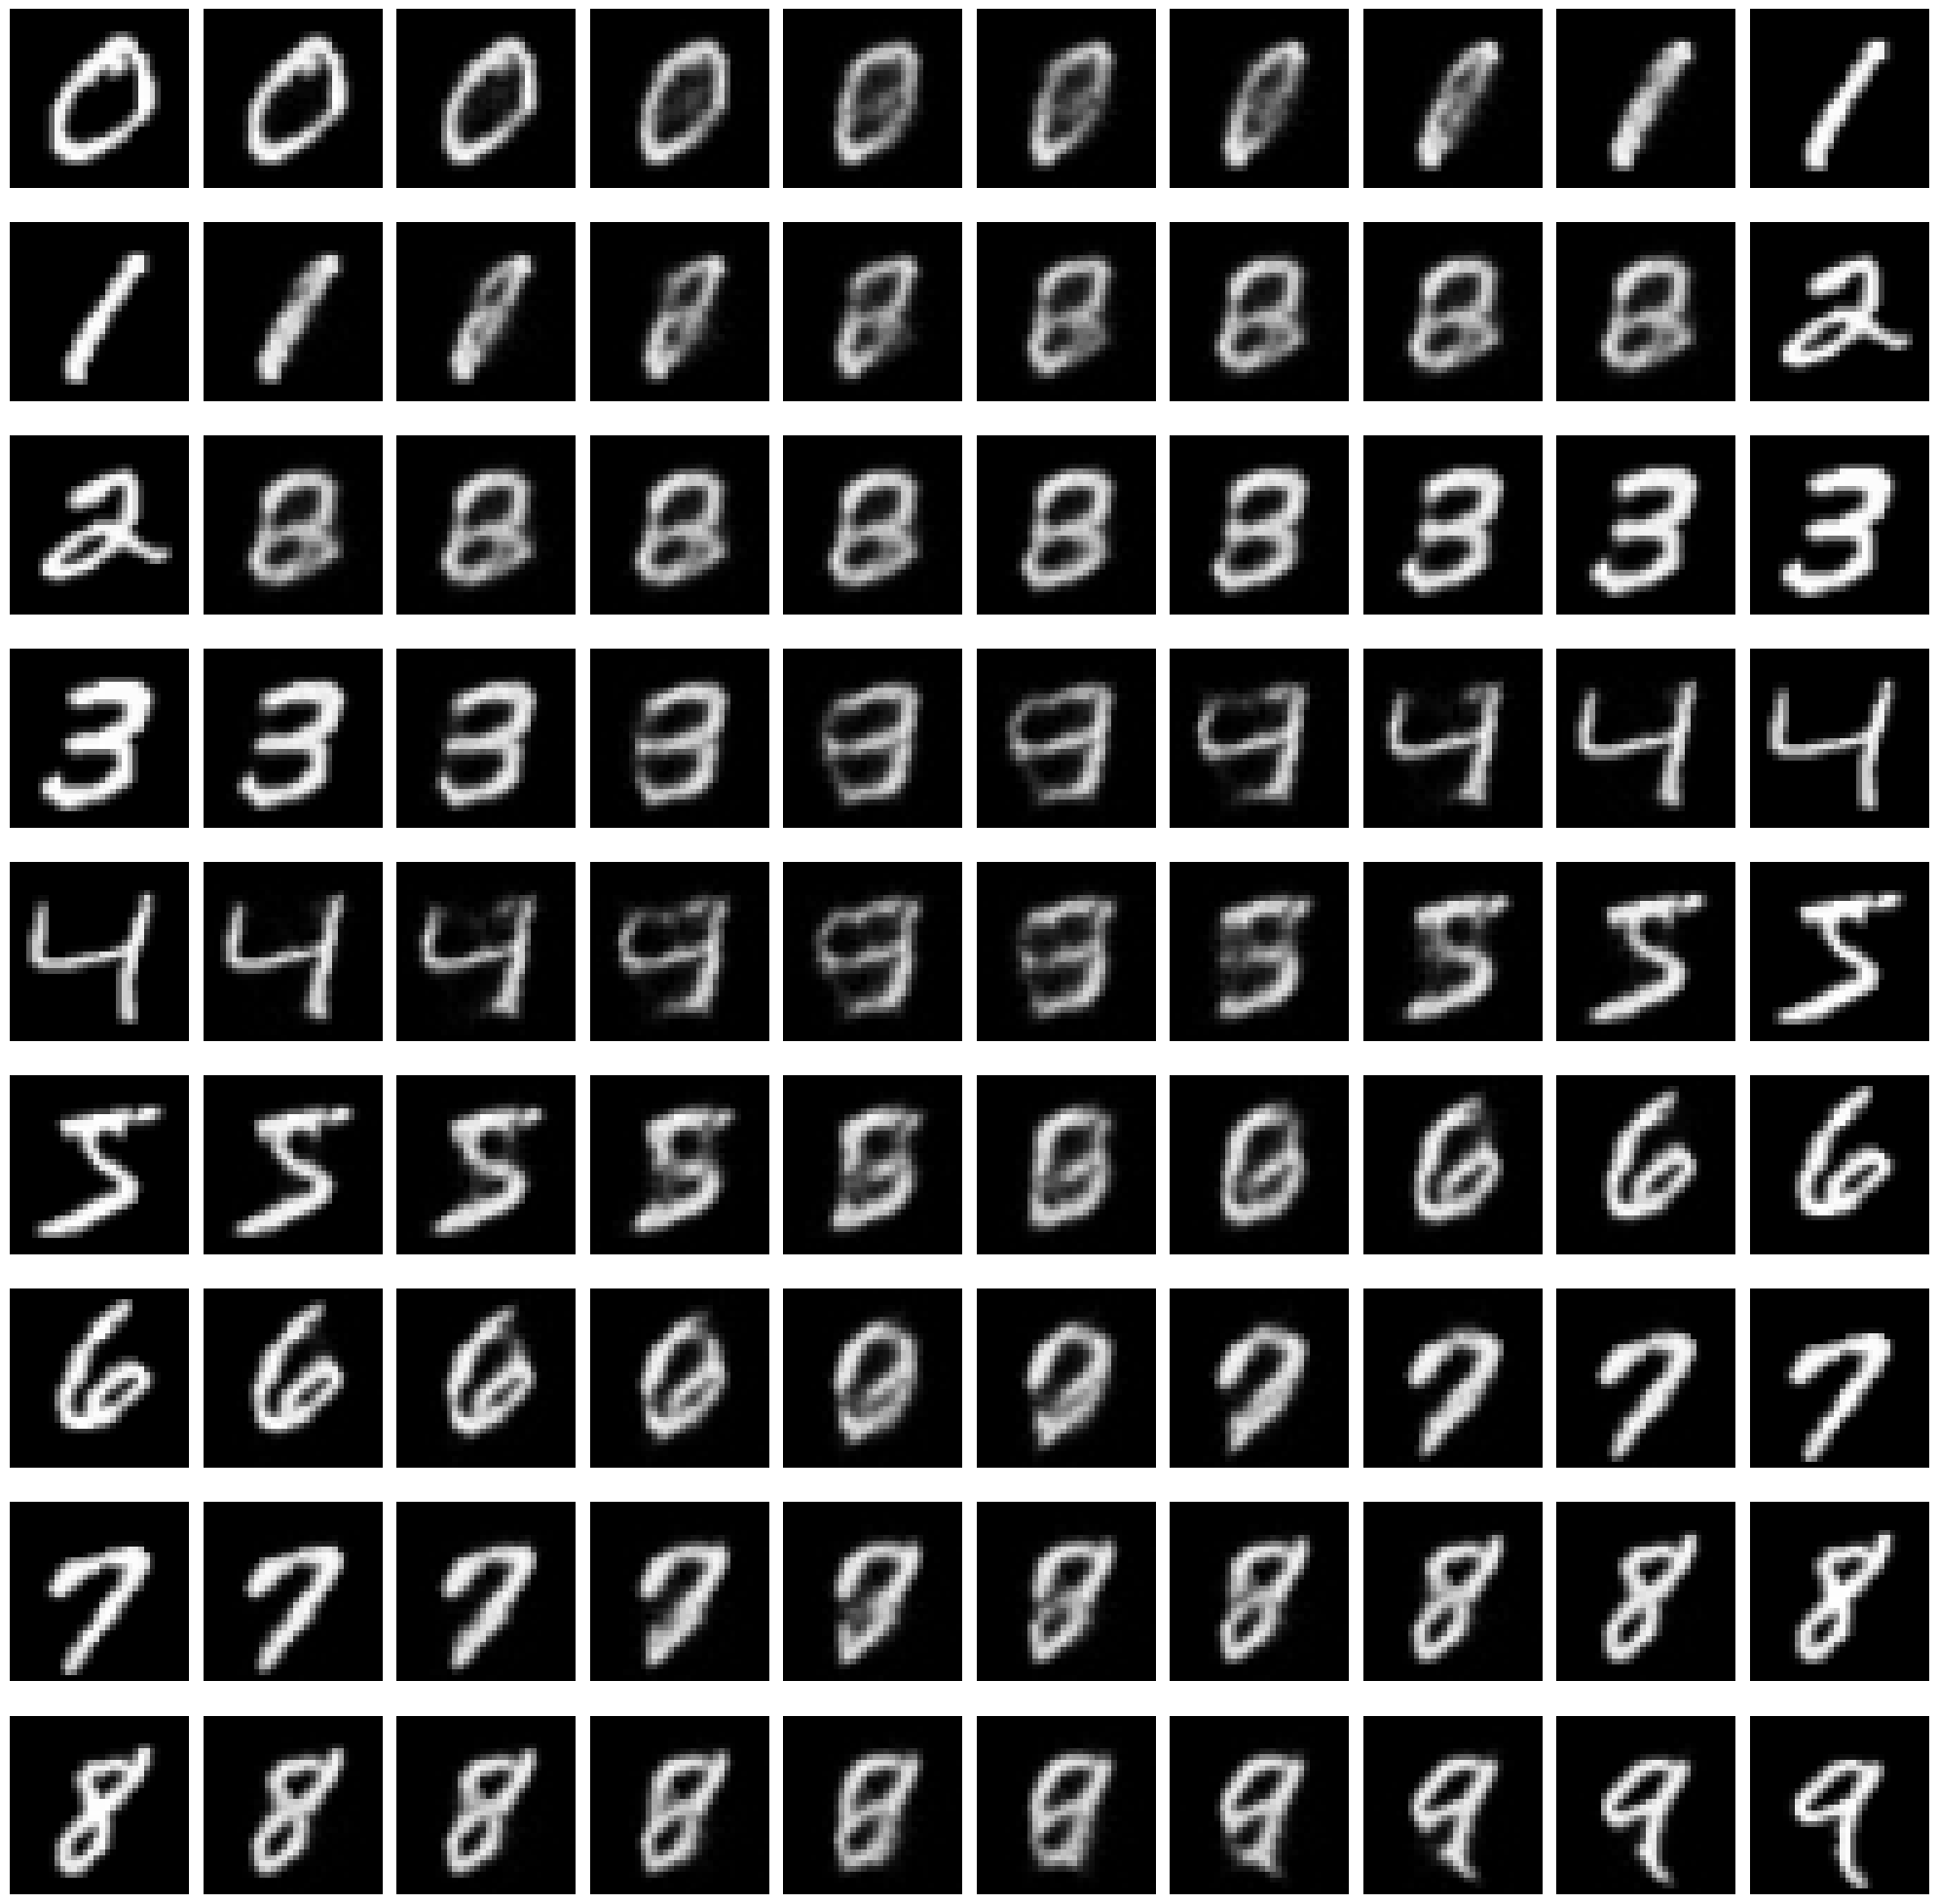

In [ ]:
# compute iso geodesics between all pairs of points
with torch.no_grad():
    iso_Omega_unsupervised_geodesics = iso_Omega_unsupervised_manifold.geodesic(data_clusters[None].to(device), data_clusters[None].to(device), t.to(device))[0].cpu()

# plot iso-geodesics
fig, axes = plt.subplots(9, steps, figsize=(int(steps / 10 * 20), 20))
axes = axes.flatten()
for i in range(10-1):
    for k in range(steps):
        axes[i*steps + k].imshow(iso_Omega_unsupervised_geodesics[i, i+1, k, 0], cmap='gray', vmin=data.min(), vmax=data.max())
        axes[i*steps + k].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(results_folder,"geodesics_Omega_iso_unsupervised.png"))
plt.show()

In [ ]:
# construct RAM
ram_unsupervised = RiemannianArchetypalMapping(Omega_unsupervised_manifold, image_cluster_end_members_unsupervised)

Archetypal Analysis solver finished prediction phase after 137 iterations with objective value 29.5067 and relative change 0.00


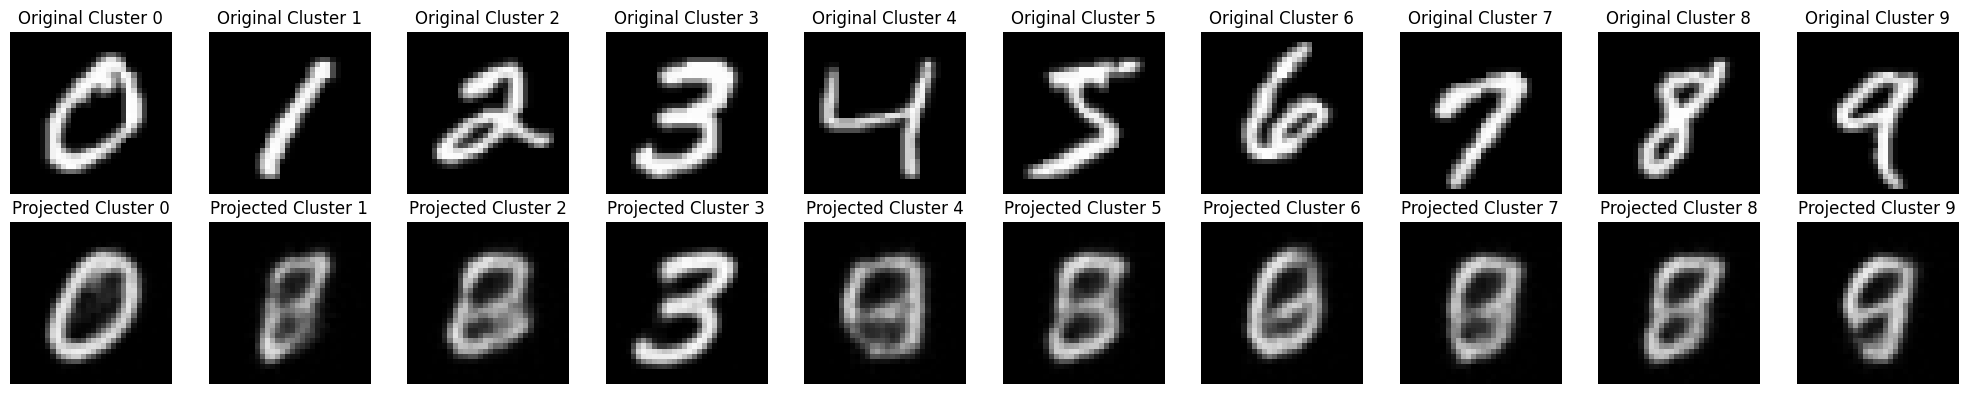

NameError: name 'ram_unsupervised_projected_data_clusters' is not defined

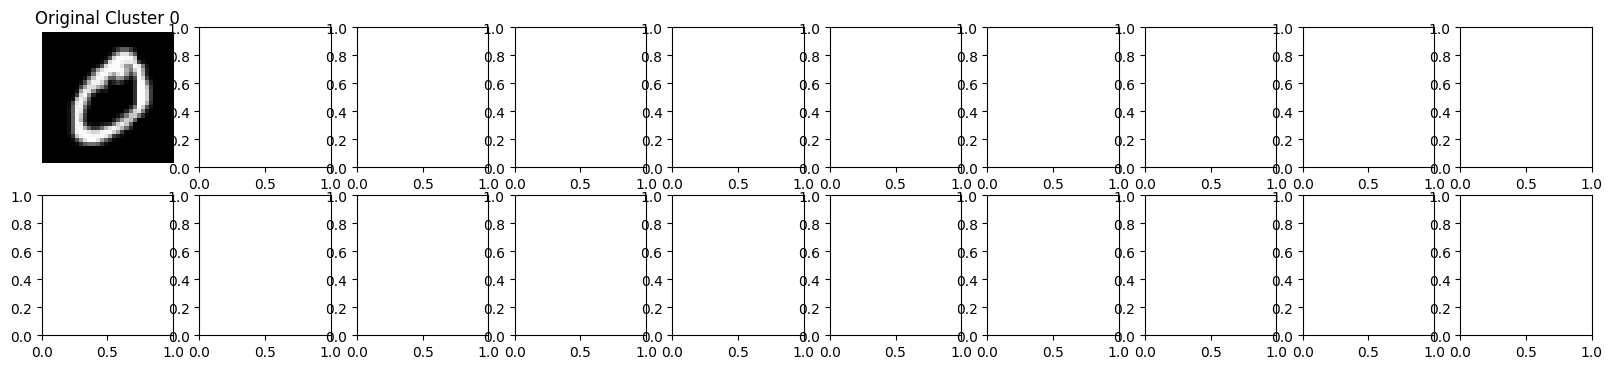

In [ ]:
with torch.no_grad():
    # project clusters
    ram_unsupervised_projected_data_clusters = ram_unsupervised.forward(data_clusters.to(device))

# plot projected clusters next to original clusters
fig, axes = plt.subplots(2, 10, figsize=(20, 4))
for i in range(10):
    axes[0, i].imshow(data_clusters[i].squeeze(), cmap='gray', vmin=data.min(), vmax=data.max())
    axes[0, i].set_title(f"Original Cluster {i}")
    axes[0, i].axis('off')

    axes[1, i].imshow(ram_unsupervised_projected_data_clusters[i].squeeze(), cmap='gray', vmin=data.min(), vmax=data.max())
    axes[1, i].set_title(f"Projected Cluster {i}")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()